In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)

coll_2014 = pd.read_csv("./data_processing/data_utils/coll2014_SNP_scheme.tsv", sep="\t")
freschi_2020 = pd.read_csv("./data_processing/data_utils/freschi2020_SNP_scheme.tsv", sep="\t")
lineages_matrix = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/lineage_matrix_Coll2014.csv", index_col=[0])

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm
from statsmodels.stats import contingency_tables, proportion

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

# def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

#     if regression:
#         model_type = 'Reg'
#     else:
#         model_type = 'CNN'
    
#     results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
#     results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

#     # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
#     return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

    if regression:
        model_type = 'LinReg'
    else:
        model_type = 'CNN'
    
    results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
    results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]


def differences_significant_CNN_Reg(df, model, variable, direction='two-sided'):

    results_1 = df.query("Model=='CNN' & Addl_Data==@model")[variable].values
    results_2 = df.query("Model=='LinReg' & Addl_Data==@model")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

cryptic_wgs_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")
df_cryptic = pd.read_csv("MIC_data/CRyPTIC_reuse_table_20231208.csv")
df_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv(os.path.join(os.path.dirname(data_dir), "isolate_WHO_catalog_variants.csv"))#.dropna(subset='variant').reset_index(drop=True)

/tmp/ipykernel_18033/1691903565.py:8: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


# Compute Essential Agreement on CRyPTIC Only to compare to https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012260

In [2]:
df_EA = pd.DataFrame(columns = ['Drug', 'CV', 'EA'])
i = 0

for drug in drugs_lst:

    if drug == 'PZA':
        model = f"{drug}_amino_acid"
    elif drug == 'BDQ':
        # model = f"{drug}_augment_amino_acid"
        model = f"{drug}_augment_lineage_amino_acid"
    else:
        # model = f"{drug}_amino_acid"
        model = f"{drug}_lineage_amino_acid"

    df_full = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv")
    cryptic_samples = df_full.query("DB_OF_ORIGIN=='CRyPTIC' & category=='test_set'").ROLLINGDB_ID.values

    print(model, len(cryptic_samples))

    if len(cryptic_samples) > 0:
        
        for cv in np.arange(len(glob.glob(f"{results_dir}/{model}/cross_validation/test_predictions_*.csv"))):
            df_pred = pd.read_csv(f"{results_dir}/{model}/cross_validation/test_predictions_{cv}.csv")
            _, _, within_doubling = boundedLoss_predict(df_pred.query("Isolate in @cryptic_samples"), y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper")
            df_EA.loc[i, :] = [drug, cv, within_doubling]
            i += 1
            
df_EA['Addl_Data'] = 'Final'
df_EA['Model'] = 'CNN'

BDQ_augment_lineage_amino_acid 1726
EMB_lineage_amino_acid 1515
ETO_lineage_amino_acid 1761
INH_lineage_amino_acid 1869
LFX_lineage_amino_acid 1549
MXF_lineage_amino_acid 1349
PZA_amino_acid 0
RIF_lineage_amino_acid 1720


In [192]:
def compute_t_distribution_confidence_intervals(df, col):

    df_summary = pd.DataFrame(df.groupby(['Drug', 'Model', 'Addl_Data'])[col].agg(['mean', 'std', 'count'])).reset_index().rename(columns={'mean': col})
    
    df_summary[f'{col}_LB'] = df_summary[col] + st.t.ppf(0.025, df=df_summary['count']-1) * df_summary['std'] / np.sqrt(df_summary['count'])
    df_summary[f'{col}_UB'] = df_summary[col] + st.t.ppf(0.975, df=df_summary['count']-1) * df_summary['std'] / np.sqrt(df_summary['count'])

    assert len(df_summary.query(f"{col} < {col}_LB")) == 0
    assert len(df_summary.query(f"{col} > {col}_UB")) == 0

    return df_summary

In [193]:
df_EA_CIs = compute_t_distribution_confidence_intervals(df_EA, 'EA')

df_EA_cryptic = pd.DataFrame({'Drug': ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'RIF'], 
                              'EA_cryptic': [0.933, 0.950, 0.913, 0.942, 0.949, 0.909, 0.929],
                              'EA_cryptic_LB': [0.923, 0.94, 0.901, 0.932, 0.940, 0.895, 0.919],
                              'EA_cryptic_UB': [0.944, 0.96, 0.924, 0.951, 0.959, 0.922, 0.94]
                             })

df_EA_cryptic = df_EA_cryptic.merge(df_EA_CIs, on='Drug')
df_EA_cryptic['diff'] = df_EA_cryptic['EA_cryptic'] - df_EA_cryptic['EA']
# df_EA_cryptic.to_csv("EA_cryptic_data.csv", index=False)

In [194]:
df_EA_cryptic[['Drug', 'EA_cryptic_LB', 'EA_cryptic_UB', 'EA_LB', 'EA_UB']]

,Drug,EA_cryptic_LB,EA_cryptic_UB,EA_LB,EA_UB
0,BDQ,0.923,0.944,0.921876,0.941392
1,EMB,0.940,0.960,0.933867,0.943096
2,ETO,0.901,0.924,0.887283,0.904427
3,INH,0.932,0.951,0.911545,0.924731
4,LFX,0.940,0.959,0.918921,0.930789
5,MXF,0.895,0.922,0.866464,0.894248
6,RIF,0.919,0.940,0.929973,0.954445


# Quantitative Model Comparison

In [3]:
def get_all_single_drug_models(drug, regression=False):
    '''
    This function gets all the models for a given drug that have model results
    '''

    # gets all directories with the drug name
    CNN_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/results.csv"))
    
    # if regression or bootstrap, then all directories must also have those corresponding directories. The regression script performs bootstrapping, so don't need to check them separately
    if regression:
        regression_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/ridge/results.csv"))
    else:
        regression_fNames = []
        
    df_combined = []
    
    for fName in CNN_fNames + regression_fNames:
        
        if 'old' not in fName:
        
            df = pd.read_csv(fName)

            model_name = '– Lineage'

            num_addl_features = 0

            if 'lineage' in fName:
                # model_name += '\n+Lineage'
                model_name = '+ Lineage'
                num_addl_features += 1

            if 'amino_acid' not in fName:
                model_name += '\n– AA Properties'
                num_addl_features += 1

            if 'tier2' in fName:
                model_name += '\n+ Tier 2 Loci'
                num_addl_features += 1

            if '_AF25' in fName:
                model_name += '\nAF = 25%'
                num_addl_features += 1
            # else:
            #     model_name += '\n AF = 75%'

            if 'augment' in fName:
                model_name += '\nBinary Augment'
                num_addl_features += 1

            # remove leading newline characters
            model_name = model_name.lstrip()

            df['Addl_Data'] = model_name
            df_combined.append(df)

    df_combined = pd.concat(df_combined)

    # check no duplicate row identifiers
    assert len(df_combined[['Model', 'Addl_Data', 'CV']].drop_duplicates()) == len(df_combined)
        
    # exponentiate errors
    for col in ['Binned_MAE', 'Binned_MSE']:
        df_combined[f'{col}_exp'] = np.exp2(df_combined[col])

    # add
    df_combined['Without_doubling'] = 1 - df_combined['Within_doubling']

    return df_combined

In [43]:
df_combined_all_drugs = pd.concat([get_all_single_drug_models(drug, regression=True) for drug in drugs_lst])

# for BDQ and PZA, remove the unaugmented cases
# df_combined_all_drugs = df_combined_all_drugs.loc[~((df_combined_all_drugs['Drug']=='BDQ') & (~df_combined_all_drugs['Addl_Data'].str.contains('Augment')))]
# df_combined_all_drugs = df_combined_all_drugs.loc[~((df_combined_all_drugs['Drug']=='PZA') & (~df_combined_all_drugs['Addl_Data'].str.contains('Augment')))]

# df_combined_all_drugs['Addl_Data'] = df_combined_all_drugs['Addl_Data'].str.replace('\nBinary Augment', '')

df_combined_all_drugs['Model'] = df_combined_all_drugs['Model'].replace('Reg', 'LinReg')

df_combined_all_drugs['Drug'] = df_combined_all_drugs['Drug'].map(abbr_drug_dict)

plotting_order = df_combined_all_drugs.sort_values(['Drug', 'Model', 'Addl_Data'], ascending=[True, False, False]).groupby(['Drug', 'Model', 'Addl_Data'], sort=False).Binned_MAE.mean().index.values

df_combined_all_drugs.to_csv("model_results_combined.csv", index=False)

# Plot for G4 Talk May 7, 2025

In [49]:
df_plot = pd.concat([df_combined_all_drugs.loc[(df_combined_all_drugs["Drug"]=='Pyrazinamide') & (df_combined_all_drugs["Addl_Data"] == '– Lineage')],
                     df_combined_all_drugs.loc[(df_combined_all_drugs["Drug"]=='Bedaquiline') & (df_combined_all_drugs["Addl_Data"] == '+ Lineage\nBinary Augment')],
                     df_combined_all_drugs.loc[(~df_combined_all_drugs["Drug"].isin(['Pyrazinamide', 'Bedaquiline'])) & (df_combined_all_drugs["Addl_Data"] == '+ Lineage')]
                    ])

len(df_plot)

70

In [50]:
col = 'Binned_MAE'
df_summary = compute_t_distribution_confidence_intervals(df_plot, col)

NameError: name 'compute_t_distribution_confidence_intervals' is not defined

In [3]:
def single_metric_forest_plot(df, col_name, xlabel_name, models_lst, convert_to_percent=False, saveName=None):

    df_summary = df.copy()
    
    offset = 0.25
    y_pos = np.arange(df_summary.Drug.nunique())
    
    colors = dict(zip(['CNN', 'LinReg', 'Catalog'], sns.color_palette("Set2", n_colors=3).as_hex()))
    
    # Plotting
    fig, ax = plt.subplots(figsize=(8, 3.5))

    if convert_to_percent:
        df_summary[[col_name, f'{col_name}_LB', f'{col_name}_UB']] *= 100
    
    # Plot each model (CNN, regression, catalog), separately with a dodge
    for i, model in enumerate(models_lst):
        
        model_data = df_summary.query("Model==@model")
        
        ax.errorbar(
            model_data[col_name], 
            y_pos + (i - len(models_lst) / 2) * offset,  # Dodge the y-position
            xerr=[
                model_data[col_name] - model_data[f'{col_name}_LB'], 
                model_data[f'{col_name}_UB'] - model_data[col_name]
            ],
            fmt='o', 
            markersize=5,
            label=model,  # Use model name as the legend label
            elinewidth=1, 
            capsize=3,
            color=colors[model],
        )
    
    # Customize the plot
    # ax.set_xlim(right=1)
    
    if convert_to_percent:
        plt.xlim(right=100)
    else:
        plt.xlim(left=0, right=1)
        
    ax.set_yticks(y_pos)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(list(model_data.Drug.unique()), fontsize=9)
    ax.set_xlabel(xlabel_name)
    # ax.set_title("Specificity of Binary and Quantiative CNN Models")
    ax.invert_yaxis()  # Invert y-axis to have the first study at the top
    ax.legend(title="", loc="lower left", fontsize=9)
    
    # Show the plot
    sns.despine()
    plt.tight_layout()

    if saveName is not None:
        plt.savefig(saveName, format='svg')
    else:
        plt.show()

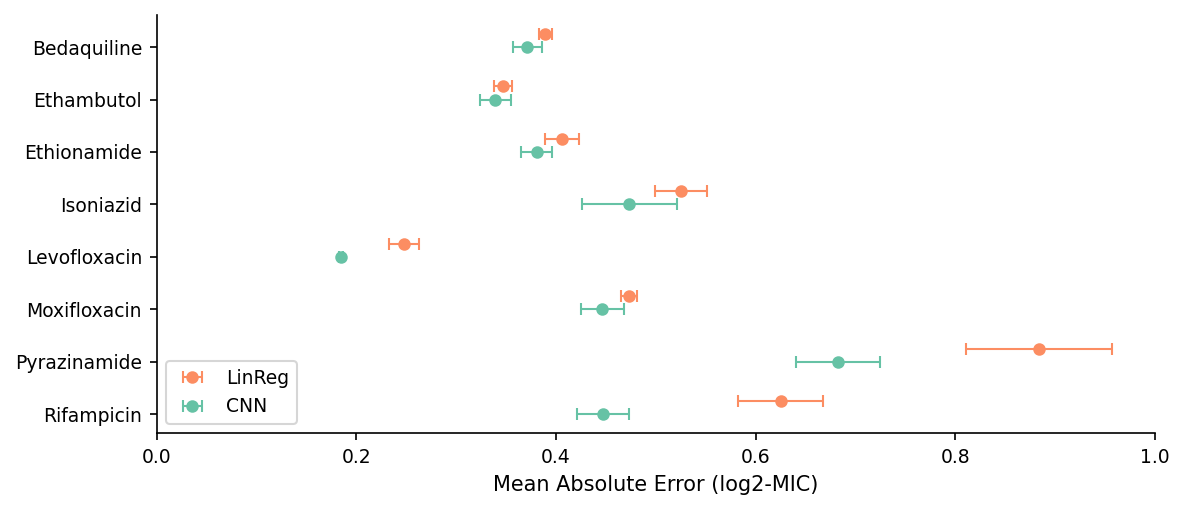

In [123]:
col_name = 'Binned_MAE'
xlabel_name = 'Mean Absolute Error (log2-MIC)'
models_lst = ['LinReg', 'CNN']
convert_to_percent = False

single_metric_forest_plot(df_summary, col_name, xlabel_name, models_lst, convert_to_percent=convert_to_percent, saveName=f"/home/sak0914/MtbQuantCNN/results/MAE_comparison.svg")

In [ ]:
df_combined_all_drugs.query("Drug=='Ethionamide'").Addl_Data.unique()

In [17]:
for group in ['+ Lineage']:

    pval = st.ttest_ind(df_combined_all_drugs.query("Drug=='Ethionamide' & Model=='CNN' & Addl_Data=='– Lineage'")['Binned_MAE'],
                        df_combined_all_drugs.query("Drug=='Ethionamide' & Model=='CNN' & Addl_Data==@group")['Binned_MAE'],
                        alternative='greater',
                        equal_var=False
                   )[1]

    print(group, pval)

+ Lineage 0.0061562075430316825


In [14]:
for group in ['+ Lineage\n+ Tier 2 Loci']:

    pval = st.ttest_ind(df_combined_all_drugs.query("Drug=='Ethionamide' & Model=='CNN' & Addl_Data=='+ Lineage'")['Binned_MAE'],
                        df_combined_all_drugs.query("Drug=='Ethionamide' & Model=='CNN' & Addl_Data==@group")['Binned_MAE'],
                        alternative='two-sided',
                        equal_var=False
                   )[1]

    print(group, pval)

+ Lineage
+ Tier 2 Loci 0.64430367977999


In [7]:
df_combined_all_drugs.query("Drug=='Bedaquiline'").Addl_Data.unique()

array(['– Lineage', '– Lineage\nBinary Augment',
       '– Lineage\nAF = 25%\nBinary Augment', '+ Lineage\nBinary Augment',
       '+ Lineage\nAF = 25%\nBinary Augment', '+ Lineage',
       '+ Lineage\n+ Tier 2 Loci', '– Lineage\n+ Tier 2 Loci'],
      dtype=object)

In [15]:
for group in ['– Lineage', '– Lineage\nBinary Augment', '+ Lineage\nBinary Augment', '+ Lineage', '+ Lineage\n+ Tier 2 Loci', '– Lineage\n+ Tier 2 Loci']:

    pval = st.ttest_ind(df_combined_all_drugs.query("Drug=='Bedaquiline' & Model=='CNN' & Addl_Data==@group")['Binned_MAE'],
                        df_combined_all_drugs.query("Drug=='Bedaquiline' & Model=='LinReg' & Addl_Data==@group")['Binned_MAE'],
                        alternative='less',
                        equal_var=False
                   )[1]

    print(group, pval)

– Lineage 0.5290172924906761
– Lineage
Binary Augment 0.5977140080764634
+ Lineage
Binary Augment 0.009919881278271871
+ Lineage 0.6946608794788005
+ Lineage
+ Tier 2 Loci 0.41023120282603404
– Lineage
+ Tier 2 Loci 0.5404695072164264


In [5]:
def plot_single_drug_model_comparison(drug, df_combined, plot_col='Binned_MAE', model_order=None, mean_bar_offset=0.2, mean_bar_width=0.1, y_min=None, y_max=None, ylabel='', title='', saveName=None):

    color_palette = dict(zip(["CNN", "LinReg", "Catalog"], sns.color_palette("Set2").as_hex()))

    if model_order is None:
        model_order = ['– Lineage', '+ Lineage'] #, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")

    # df_combined['Model'] = df_combined['Model'].replace('LinReg', 'Regression')

    # convert to percentages
    if 'doubling' in plot_col:
        df_combined[plot_col] *= 100

    fig_width = 1.2 * df_combined.Addl_Data.nunique()
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))
    
    sns.stripplot(data=df_combined,
                  x='Addl_Data',
                  order=model_order,
                  y=plot_col,
                  hue='Model',
                  hue_order=['LinReg', 'CNN'],
                  palette=color_palette,
                  dodge=True,
                  jitter=True,
                  edgecolor='black',
                  linewidth=0.75,
                  size=5,
                  alpha=0.8,
                  zorder=1,
                  ax=ax
                  #log_scale=2
                 )
    
    for i, model_name in enumerate(model_order):
        for k, model_type in enumerate(['LinReg', 'CNN']):
            
            median_error = df_combined.query(f"Model==@model_type & Addl_Data==@model_name")[plot_col].median()
    
            if k == 0:
                xpos = ax.get_xticks()[i] - mean_bar_offset
            else:
                xpos = ax.get_xticks()[i] + mean_bar_offset
                
            ax.hlines(y=median_error, xmin=xpos-mean_bar_width, xmax=xpos+mean_bar_width, color=color_palette[model_type], zorder=0)

    ref_font_size = 8
    
    plt.xlabel('', fontsize=ref_font_size)
    plt.ylabel(ylabel, fontsize=ref_font_size)
    plt.title(f'{abbr_drug_dict[drug]}', fontsize=ref_font_size)
    
    plt.xticks(fontsize=ref_font_size-1.5)
    plt.yticks(fontsize=ref_font_size-1)
    plt.legend(title='', fontsize=ref_font_size-1, loc='best', ncols=2)
    
    # try:
    #     ax.get_legend().remove()
    # except:
    #     pass

    if y_max is None:
        y_max = df_combined[plot_col].max()*1.05
    
    plt.ylim(bottom=y_min, top=y_max)
    sns.despine()
    plt.tight_layout()

    if saveName is None:
        plt.show()
    else:
    
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
        
        plt.savefig(saveName, format='svg', bbox_inches='tight')

In [6]:
def get_performance_comparison_CNN_Reg(drug, df_combined, model_order=None, plot_col='Binned_MAE', y_min=None, saveName=None):
    
    # df_combined = get_all_single_drug_models(drug, regression=True)
    
    if model_order is None:
        # model_order = ['- Lineage', '+ Lineage', '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci'] #['+AA Properties', '+Lineage\n+AA Properties']
        model_order = df_combined.Addl_Data.unique()

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")
    
    if 'exp' in plot_col.lower():
        plot_y_min = 1
        title = 'Mean Absolute Error (Doublings)'
        ylabel = 'Relative Error'
        save_name = 'MAE_exp'
    elif 'doubling' in plot_col.lower():
        plot_y_min = 0
        title = 'Essential Disagreement'
        ylabel = 'Essential Disagreement'
        save_name = 'EA'
    elif plot_col in ['Spearman', 'Pearson']:
        ylabel = plot_col
        title = plot_col
        plot_y_min = 0.5
        save_name = plot_col
    else:
        plot_y_min = 0
        title = 'Mean Absolute Error'
        ylabel = 'Mean Absolute Error (log2-MIC)'
        save_name = 'MAE'

    if '- Lineage\n+ Tier 2 Loci' in model_order:
        save_name += "_tier2"

    # override
    if y_min is not None:
        plot_y_min = y_min

    plot_single_drug_model_comparison(drug, df_combined, plot_col=plot_col, model_order=model_order, mean_bar_width=0.15, y_min=plot_y_min, ylabel=ylabel, title=title, saveName=saveName)        
            
    df_pvals = pd.DataFrame(columns=['Model', 'Variable', 'CNN_better_pval', 'Reg_better_pval', 'Two_sided_pval'])
    i = 0

    for model in df_combined.Addl_Data.unique():
        df_pvals.loc[i, :] = [model.replace('\n', ','), 
                              plot_col, 
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='less'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='greater'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='two-sided')
                             ]
        i += 1
        
        # df_pvals.loc[i, :] = [model.replace('\n', ','), 
        #                       'Without_doubling',
        #                       differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='less'),
        #                       differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='greater')
        #                      ]
        # i += 1

    # # perform FDR correction at the single-drug level
    # _, cnn_better_bh_pvals, _, _ = sm.multipletests(df_pvals['CNN_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_CNN_better_pval'] = cnn_better_bh_pvals
    
    # _, reg_better_bh_pvals, _, _ = sm.multipletests(df_pvals['Reg_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_Reg_better_pval'] = reg_better_bh_pvals
    
    df_pvals['Drug'] = drug
    
    return df_pvals

# 0. Compare +/- Augmentation for Bedaquiline and Pyrazinamide

BDQ
PZA


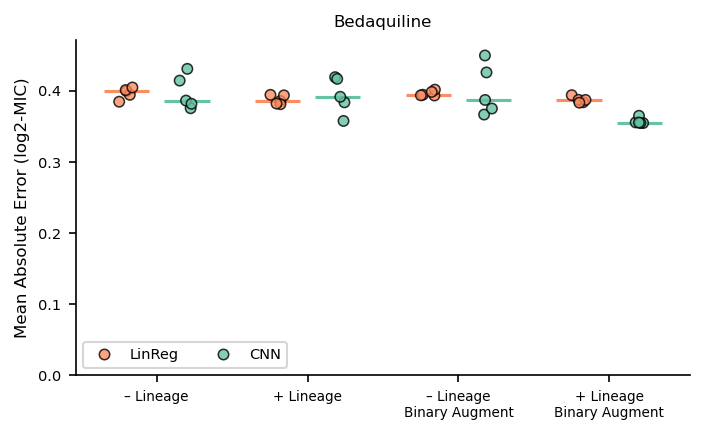

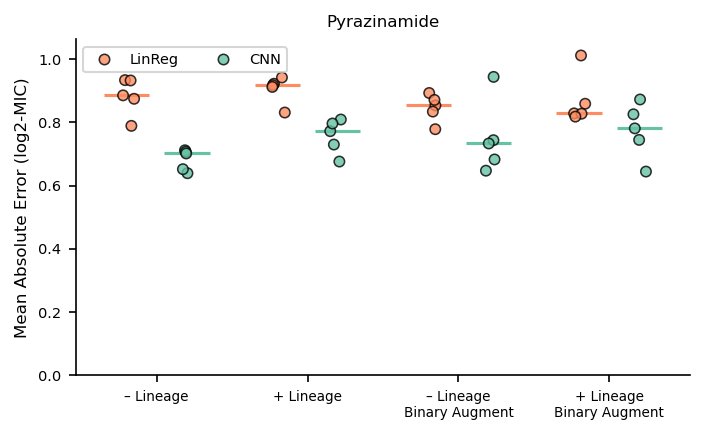

In [7]:
for drug in os.listdir(data_dir):

    if drug in ['PZA', 'BDQ']:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        model_order = ['– Lineage', '+ Lineage', '– Lineage\nBinary Augment', '+ Lineage\nBinary Augment']
        
        _ = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = model_order,
                                                      plot_col='Binned_MAE', 
                                                      saveName=f"results/{full_drug_name}/MAE_augment_compare.svg"
                                                     )

In [8]:
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Bedaquiline'"), '– Lineage\nBinary Augment', '– Lineage', 'Binned_MAE', regression=False, direction='less')

0.5628318799032699

In [9]:
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Bedaquiline'"), '+ Lineage\nBinary Augment', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

0.015407666657798044

In [10]:
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Pyrazinamide'"), '– Lineage\nBinary Augment', '– Lineage', 'Binned_MAE', regression=False, direction='less')

0.8671345802452992

In [11]:
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Pyrazinamide'"), '+ Lineage\nBinary Augment', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

0.6384146796965156

In [15]:
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Pyrazinamide'"), '+ Lineage\nBinary Augment', '– Lineage\nBinary Augment', 'Binned_MAE', regression=False, direction='less')

0.6370094650566578

In [22]:
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\nBinary Augment'].query("Drug=='Pyrazinamide' & Model=='CNN'").Binned_MAE,
             df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\nBinary Augment'].query("Drug=='Pyrazinamide' & Model=='CNN'").Binned_MAE,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=0.364017422980435, pvalue=0.6370094650566578, df=7.4326209052525085)

In [45]:
# keep the augmented models for bedaquiline and pyrazinamide
df_combined_all_drugs = df_combined_all_drugs.loc[~((df_combined_all_drugs['Drug']=='Bedaquiline') & (~df_combined_all_drugs['Addl_Data'].str.contains('Augment')))]
df_combined_all_drugs = df_combined_all_drugs.loc[~((df_combined_all_drugs['Drug']=='Pyrazinamide') & (~df_combined_all_drugs['Addl_Data'].str.contains('Augment')))]

# rename them that it will be the main model
df_combined_all_drugs['Addl_Data'] = df_combined_all_drugs['Addl_Data'].str.replace('\nBinary Augment', '')

# 1. Does lineage not harm predictions? If so, keep

In [46]:
for drug in drugs_lst:
    
    full_drug_name = abbr_drug_dict[drug]

    two_sided_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='two-sided')

    if two_sided_pval <= 0.05:
        
        lineage_better_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='greater')
        lineage_worse_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

        with_lineage_MAE = df_combined_all_drugs.query("Drug==@full_drug_name & Addl_Data == '+ Lineage' & Model=='CNN'").Binned_MAE.mean()
        no_lineage_MAE = df_combined_all_drugs.query("Drug==@full_drug_name & Addl_Data == '– Lineage' & Model=='CNN'").Binned_MAE.mean()

        if lineage_better_pval <= 0.05:
            print(f"{full_drug_name}: + Lineage better, pval = {lineage_better_pval}, Δ = {with_lineage_MAE - no_lineage_MAE}")
        else:
            print(f"{full_drug_name}: + Lineage worse, pval = {lineage_worse_pval} Δ = {with_lineage_MAE - no_lineage_MAE}")

    else:
        print(f"{full_drug_name}: No difference, pval = {two_sided_pval}")

Bedaquiline: No difference, pval = 0.05013434692232715
Ethambutol: No difference, pval = 0.4292026267173312
Ethionamide: + Lineage better, pval = 0.0061562075430316825, Δ = -0.026289860497655304
Isoniazid: No difference, pval = 0.913389944348936
Levofloxacin: + Lineage better, pval = 5.561897240128103e-05, Δ = -0.005196031388372935
Moxifloxacin: + Lineage better, pval = 0.00018895924691703087, Δ = -0.11532436803139123
Pyrazinamide: No difference, pval = 0.7259810698866845
Rifampicin: No difference, pval = 0.5514022084404424


In [55]:
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.05, 'Asterisk'] = '*'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.01, 'Asterisk'] = '**'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.001, 'Asterisk'] = '***'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.0001, 'Asterisk'] = '****'

In [57]:
df_pvals_combined.query("Model=='+ Lineage'")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
1,+ Lineage,Binned_MAE,0.392262,0.607738,0.784524,BDQ,n
1,+ Lineage,Binned_MAE,0.13743,0.86257,0.274861,EMB,n
1,+ Lineage,Binned_MAE,0.008179,0.991821,0.016358,ETO,**
1,+ Lineage,Binned_MAE,0.018043,0.981957,0.036085,INH,*
1,+ Lineage,Binned_MAE,0.000143,0.999857,0.000286,LFX,***
1,+ Lineage,Binned_MAE,0.010595,0.989405,0.02119,MXF,*
1,+ Lineage,Binned_MAE,0.147802,0.852198,0.295604,PZA,n
1,+ Lineage,Binned_MAE,0.000017,0.999983,0.000033,RIF,****


In [12]:
# df_pvals_combined_EA.query("CNN_better_pval <= 0.05").sort_values("CNN_better_pval")

In [13]:
# df_pvals_combined_EA.query("Reg_better_pval <= 0.05").sort_values("CNN_better_pval")

In [62]:
df_pvals_combined.query("Model == '+ Lineage'").sort_values("CNN_better_pval")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
1,+ Lineage,Binned_MAE,0.000017,0.999983,0.000033,RIF,****
1,+ Lineage,Binned_MAE,0.000143,0.999857,0.000286,LFX,***
1,+ Lineage,Binned_MAE,0.008179,0.991821,0.016358,ETO,**
1,+ Lineage,Binned_MAE,0.010595,0.989405,0.02119,MXF,*
1,+ Lineage,Binned_MAE,0.018043,0.981957,0.036085,INH,*
1,+ Lineage,Binned_MAE,0.13743,0.86257,0.274861,EMB,n
1,+ Lineage,Binned_MAE,0.147802,0.852198,0.295604,PZA,n
1,+ Lineage,Binned_MAE,0.392262,0.607738,0.784524,BDQ,n


In [63]:
for variable in ['Binned_MAE', 'Within_doubling']:

    min_val = df_combined_all_drugs.query("Addl_Data in ['– Lineage', '+ Lineage'] & Model=='CNN'").groupby('Drug')[variable].mean().min()
    max_val = df_combined_all_drugs.query("Addl_Data in ['– Lineage', '+ Lineage'] & Model=='CNN'").groupby('Drug')[variable].mean().max()

    print(variable, min_val, max_val)

Binned_MAE 0.18726626284719483 0.541480102907624
Within_doubling 0.7736017897091723 0.9217307692307692


In [ ]:
df_pvals_combined = []

for drug in os.listdir(data_dir):

    if drug in drugs_lst:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        df_pvals = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = ['– Lineage', '+ Lineage'],
                                                      plot_col='Binned_MAE', 
                                                      saveName=f"results/{full_drug_name}/MAE.svg"
                                                     )
        df_pvals_combined.append(df_pvals)

df_pvals_combined = pd.concat(df_pvals_combined)

# 2. Pyrazinamide comparison, +/- AA Properties

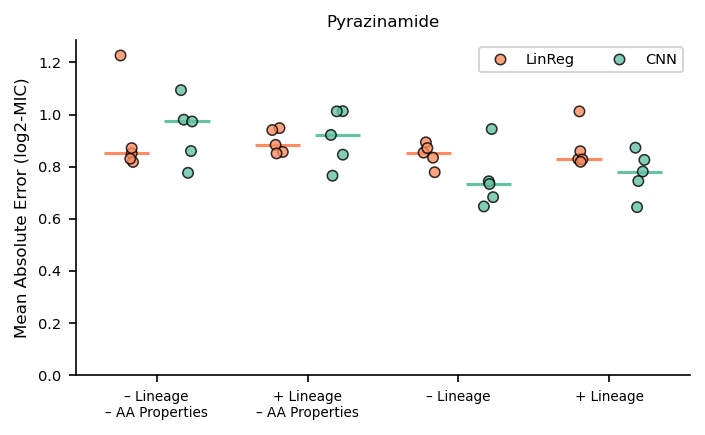

In [47]:
drug = 'PZA'
full_drug_name = abbr_drug_dict[drug]


model_order = ['– Lineage\n– AA Properties',
               '+ Lineage\n– AA Properties',
                '– Lineage', 
               '+ Lineage',
              ]

df_pvals_PZA = get_performance_comparison_CNN_Reg(drug, 
                                                  df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                  model_order=model_order, 
                                                  plot_col='Binned_MAE', 
                                                  y_min=0, 
                                                  saveName=f"results/{full_drug_name}/MAE_AA_property_compare.svg"
                                                 )

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --augment --predict --insilico-muts --locus pncA
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --augment --predict --insilico-muts --locus clpC1
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --augment --predict --insilico-muts --locus rpsA
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --augment --predict --insilico-muts --locus panD

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --augment --predict --TRUST
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --amino-acid --augment --predict --TRUST

In [ ]:
python3 analysis/addl_data_predictions.py -c config_files/config_pza.yaml --lineage --amino-acid --augment --predict --saturation-muts --gene pncA

In [49]:
df_pvals_PZA

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug
0,"– Lineage,– AA Properties",Binned_MAE,0.569626,0.430374,0.860748,PZA
1,– Lineage,Binned_MAE,0.070356,0.929644,0.140711,PZA
2,"+ Lineage,– AA Properties",Binned_MAE,0.61276,0.38724,0.77448,PZA
3,+ Lineage,Binned_MAE,0.055345,0.944655,0.110689,PZA


In [56]:
differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '– Lineage',
                                   '– Lineage\n– AA Properties',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.018998937545271447

In [55]:
differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '+ Lineage',
                                   '+ Lineage\n– AA Properties',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.02886183820776799

In [61]:
df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\n– AA Properties'].query("Drug==@full_drug_name & Model=='CNN'").Binned_MAE.mean() - df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage'].query("Drug==@full_drug_name & Model=='CNN'").Binned_MAE.mean()

0.1377113590095992

# Binary Metrics comparison to WHO-based Predictions

In [100]:
# df_binary = pd.read_excel("analysis/binary_CNN_paper_Supp1.xlsx", sheet_name=None)

# if len(df_binary.keys()) == 1:
#     df_binary = df_binary[list(df_binary.keys())[0]]

In [101]:
# binary_results_drugs_lst = ['RIFAMPICIN', 'ISONIAZID', 'LEVOFLOXACIN', 'MOXIFLOXACIN', 'ETHAMBUTOL', 'ETHIONAMIDE', 'PYRAZINAMIDE']

# df_binary_cnn_summary = df_binary.query("Drug in @binary_results_drugs_lst & model=='SD-CNN'").groupby('Drug')[['sens', 'spec']].mean().reset_index()
# df_binary_cnn_summary_std = df_binary.query("Drug in @binary_results_drugs_lst & model=='SD-CNN'").groupby('Drug')[['sens', 'spec']].std().reset_index()

# df_quant_cnn_summary = df_combined_all_drugs.query("Addl_Data=='+ Lineage' & Model=='CNN'").groupby('Drug')[['Sensitivity', 'Specificity']].mean().reset_index().rename(columns={'Sensitivity': 'sens', 'Specificity': 'spec'})
# df_quant_cnn_summary_std = df_combined_all_drugs.query("Addl_Data=='+ Lineage' & Model=='CNN'").groupby('Drug')[['Sensitivity', 'Specificity']].std().reset_index().rename(columns={'Sensitivity': 'sens', 'Specificity': 'spec'})

In [135]:
WHO_catalog_sample_counts = pd.read_csv("~/who-analysis/data/samples_summary.csv")

In [55]:
def compute_exact_confidence_intervals(res_df, alpha):
    
    res_df = res_df.reset_index(drop=True)

    # add exact binomial confidence intervals for the binomial variables. The other two will be done in another function
    for i, row in res_df.iterrows():
        
        # will be null for the principal components, so skip them
        if not pd.isnull(row["TP"]):

                        # binomtest requires the numbers to be integers
            row[["TP", "FP", "TN", "FN"]] = row[["TP", "FP", "TN", "FN"]].astype(int)
            
            # Sensitivity: TP / (TP + FN)
            ci = st.binomtest(k=row["TP"], n=row["TP"] + row["FN"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["Sens_LB", "Sens_UB"]] = [ci.low, ci.high]
            
            # Specificity: TN / (TN + FP)
            ci = st.binomtest(k=row["TN"], n=row["TN"] + row["FP"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["Spec_LB", "Spec_UB"]] = [ci.low, ci.high]

            # F1 score: 2TP / (2TP + FN + FP)
            ci = st.binomtest(k=2*row["TP"], n=2*row["TP"] + row['FN'] + row["FP"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["F1_LB", "F1_UB"]] = [ci.low, ci.high]
    
    return res_df

In [56]:
def read_in_process_binary_predictions(model_path, cc):

    df = pd.read_csv(f"{results_dir}/{model_path}/test_predictions.csv").query("Span_CC==0")

    # have to change names so that we can use the y_pred and y_test column names
    df.rename(columns={'y_test': 'y_test_log2', 'y_pred': 'y_pred_log2'}, inplace=True)

    cc = np.log2(cc)

    df.loc[df['y_test_log2'] > cc, 'y_test'] = 1
    df.loc[df['y_test_log2'] <= cc, 'y_test'] = 0
    
    df.loc[df['y_pred_log2'] > cc, 'y_pred'] = 1
    df.loc[df['y_pred_log2'] <= cc, 'y_pred'] = 0

    return df


def compute_confusion_matrix_values(df):

    df.loc[(df['y_pred']==1) & (df['y_test']==0), 'Group'] = 'FP'
    df.loc[(df['y_pred']==1) & (df['y_test']==1), 'Group'] = 'TP'
    df.loc[(df['y_pred']==0) & (df['y_test']==0), 'Group'] = 'TN'
    df.loc[(df['y_pred']==0) & (df['y_test']==1), 'Group'] = 'FN'

    return pd.DataFrame(df.Group.value_counts()).T

In [64]:
df_binary_statistics_CNN_catalog = []

for drug in drugs_lst:

    if drug in ['PZA']:
        model_path = f"{drug}_amino_acid"
    elif drug == 'BDQ':
        model_path = f"{drug}_augment_lineage_amino_acid"
    else:
        model_path = f"{drug}_lineage_amino_acid"

    cc = cc_dict[drug]

    df_CNN = read_in_process_binary_predictions(model_path, cc)

    # add sensitivity and specificity 95% confidence intervals
    df_CNN = compute_exact_confidence_intervals(compute_confusion_matrix_values(df_CNN), 0.05)
    df_CNN['Drug'] = abbr_drug_dict[drug]
    df_CNN['Model'] = 'CNN'

    df_catalog = pd.read_csv(f"{results_dir}/{drug}/catalog_test_predictions_V2.csv")

    # add sensitivity and specificity 95% confidence intervals
    df_catalog = compute_exact_confidence_intervals(compute_confusion_matrix_values(df_catalog), 0.05)
    df_catalog['Drug'] = abbr_drug_dict[drug]
    df_catalog['Model'] = 'Catalog'

    df_binary_statistics_CNN_catalog.append(df_CNN)
    df_binary_statistics_CNN_catalog.append(df_catalog)

df_binary_statistics_CNN_catalog = pd.concat(df_binary_statistics_CNN_catalog)

# add the overall stats
df_binary_statistics_CNN_catalog['Sens'] = df_binary_statistics_CNN_catalog['TP'] / (df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FN'])
df_binary_statistics_CNN_catalog['Spec'] = df_binary_statistics_CNN_catalog['TN'] / (df_binary_statistics_CNN_catalog['TN'] + df_binary_statistics_CNN_catalog['FP'])

df_binary_statistics_CNN_catalog['F1'] = 2 * df_binary_statistics_CNN_catalog['TP'] / (2 * df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FP'] + df_binary_statistics_CNN_catalog['FN'])

In [138]:
WHO_catalog_sample_counts.query("Drug in @df_binary_statistics_CNN_catalog.Drug").sort_values('Genos')

,Drug,Genos,SNP_Matrix,ALL_Phenos,WHO_Phenos,ALL_Only,MIC,ALL_MIC,Tier1_LOF,Tier1_Inframe,Tier2_LOF,Tier2_Inframe
1,Bedaquiline,14135,14135,14135,2165,11970,12659,11231,801,18,72.0,127.0
6,Ethionamide,20936,20936,20936,5999,14937,12688,9585,2273,145,670.0,30.0
13,Pyrazinamide,21319,21319,21319,19889,1430,1146,0,637,70,5436.0,88.0
11,Moxifloxacin,22783,22783,22783,8439,14344,12749,10059,0,13,623.0,38.0
9,Levofloxacin,27576,27576,27576,12441,15135,11445,8934,1,24,700.0,49.0
5,Ethambutol,45515,45515,45515,33240,12275,12914,9721,1,49,1202.0,106.0
14,Rifampicin,47730,47730,47730,35401,12329,12874,7115,0,180,1123.0,115.0
7,Isoniazid,48706,48706,48706,34881,13825,12825,7018,291,36,15431.0,102.0


In [ ]:
on 14-48000

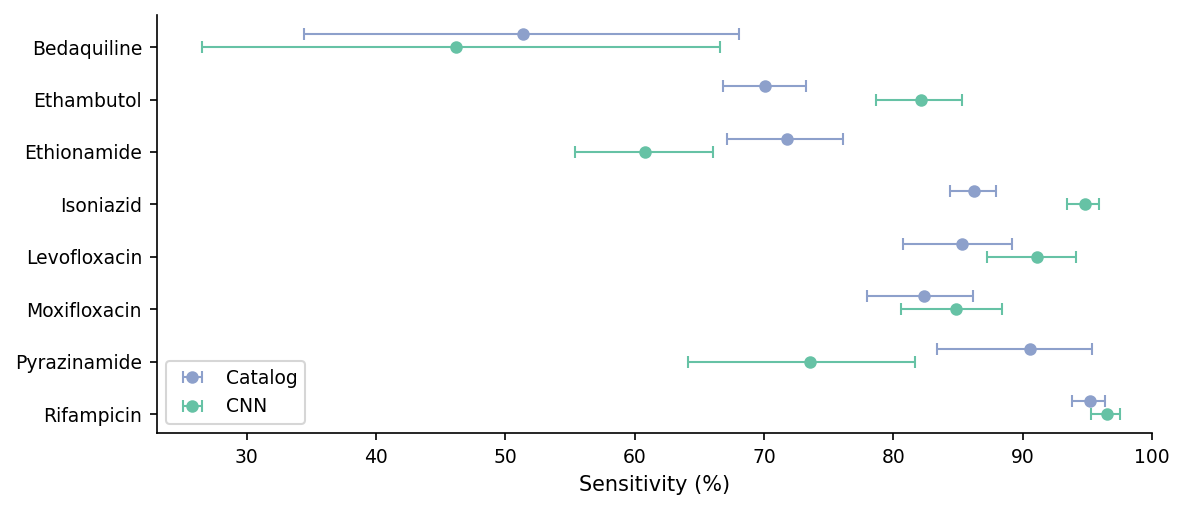

In [43]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Sens', 'Sensitivity (%)', ['Catalog', 'CNN'], convert_to_percent=True)#, saveName=f"/home/sak0914/MtbQuantCNN/results/Sensitivity_comparison.svg")

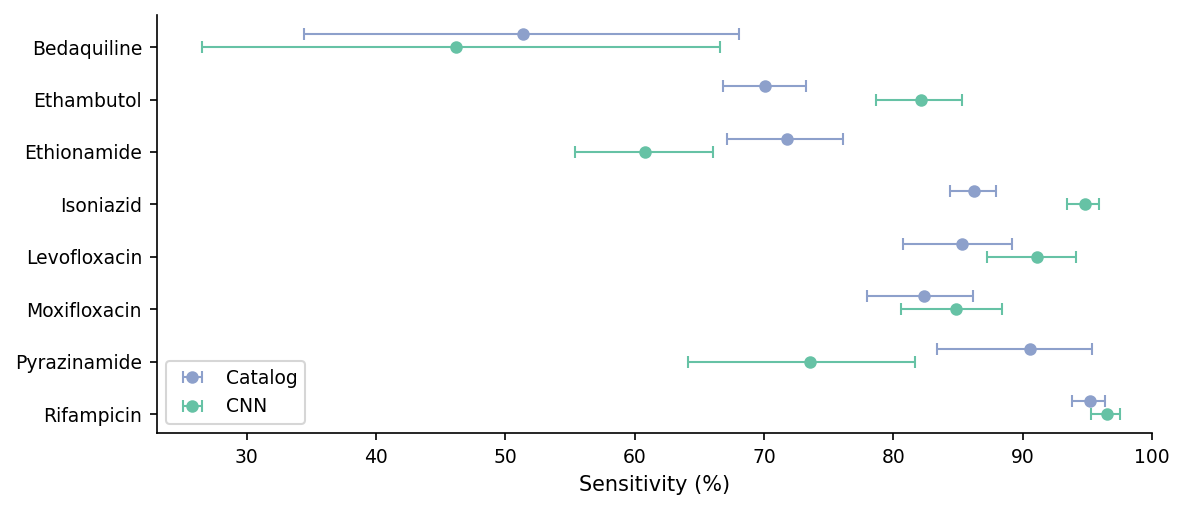

In [9]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Sens', 'Sensitivity (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/Sensitivity_comparison.svg")

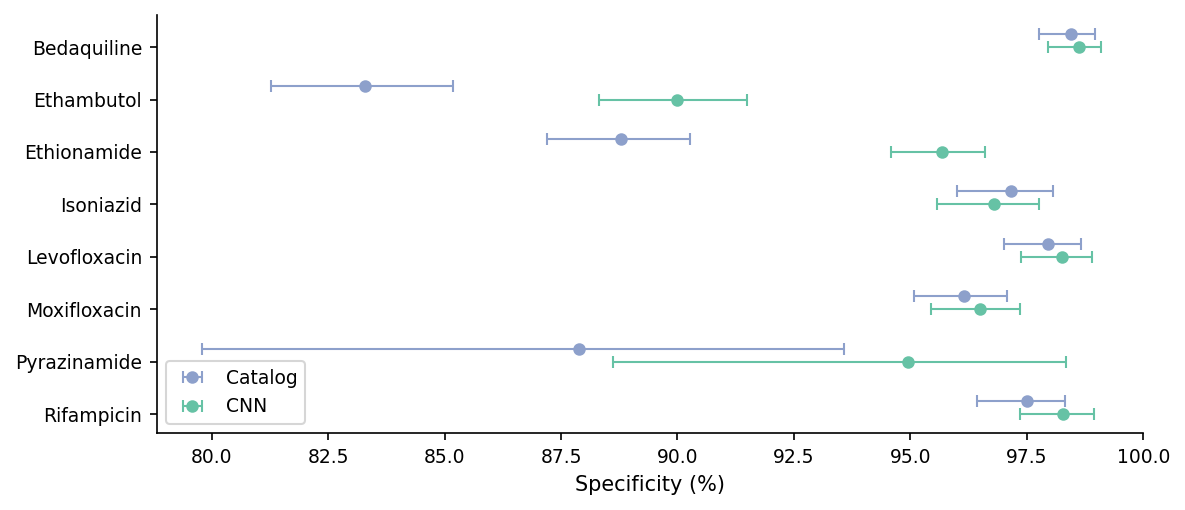

In [139]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Spec', 'Specificity (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/Specificity_comparison.svg")

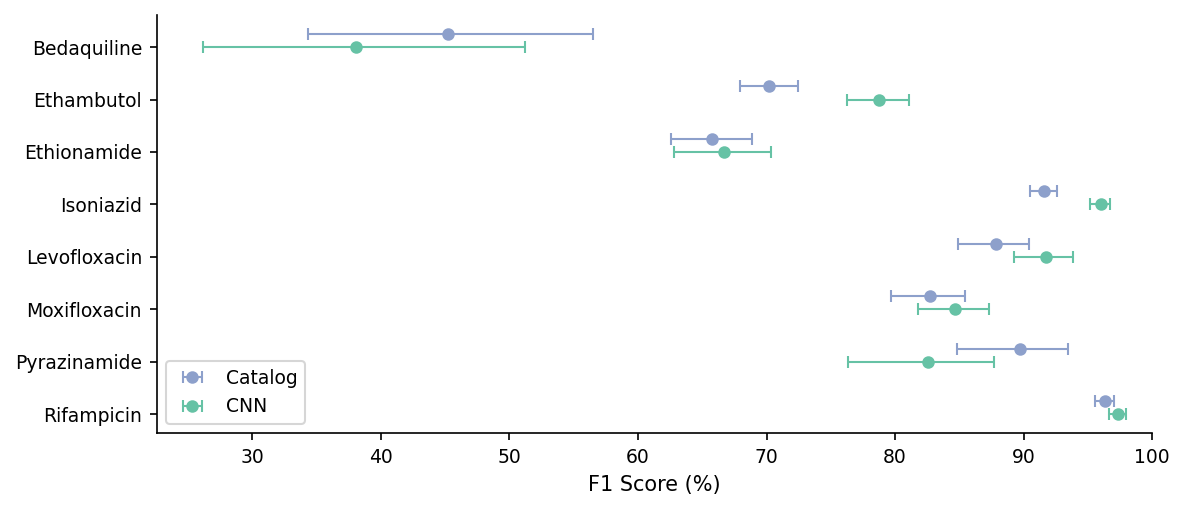

In [140]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'F1', 'F1 Score (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/F1_comparison.svg")

In [110]:
# df_F1_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='F1')
# df_F1_comparison['Diff'] = df_F1_comparison['CNN'] - df_F1_comparison['Catalog']

df_Sens_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='Sens')
df_Sens_comparison['Diff'] = df_Sens_comparison['CNN'] - df_Sens_comparison['Catalog']

df_Spec_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='Spec')
df_Spec_comparison['Diff'] = df_Spec_comparison['CNN'] - df_Spec_comparison['Catalog']

In [113]:
df_Sens_comparison.Diff.min()*100, df_Sens_comparison.Diff.mean()*100, df_Sens_comparison.Diff.max()*100

(-16.981132075471706, -0.3574917128209981, 12.063892391761243)

In [114]:
df_Spec_comparison.Diff.min()*100, df_Spec_comparison.Diff.mean()*100, df_Spec_comparison.Diff.max()*100

(-0.36663611365719273, 2.732687249537075, 7.070707070707072)

In [118]:
df_binary_statistics_CNN_catalog.set_index(['Drug', 'Model']).to_csv("./supplement/binary_classification_metrics.csv")

In [115]:
df_Sens_comparison

Model,CNN,Catalog,Diff
Drug,,,
Bedaquiline,0.461538,0.513514,-0.051975
Ethambutol,0.821494,0.700855,0.120639
Ethionamide,0.608309,0.717445,-0.109136
Isoniazid,0.947846,0.862046,0.085800
Levofloxacin,0.911263,0.853242,0.058020
Moxifloxacin,0.848138,0.823362,0.024776
Pyrazinamide,0.735849,0.905660,-0.169811
Rifampicin,0.965035,0.951947,0.013088


## Are the sensitivity and specificity differences significant

Sensitivity: BDQ, PZA

In [125]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
                                             alternative='smaller'
                                            )
    
    print(drug, pval)

Bedaquiline 0.3422782456691239
Ethambutol 0.9999997744550297
Ethionamide 0.0008259265079300101
Isoniazid 0.99999999999999
Levofloxacin 0.9853287014613075
Moxifloxacin 0.8117960241495519
Pyrazinamide 0.0006340525435584146
Rifampicin 0.9437417429938992


In [131]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TN'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TN', 'FP']].values.sum(axis=1),
                                             alternative='larger'
                                            )
    
    print(drug, pval)

Bedaquiline 0.33901642240501356
Ethambutol 5.8722057474915084e-08
Ethionamide 4.258252952601166e-14
Isoniazid 0.6914574192904337
Levofloxacin 0.2799811865945674
Moxifloxacin 0.3158777312590103
Pyrazinamide 0.0378921015642033
Rifampicin 0.09688848161720942


# Investigation of CNN Poor Sensitivities

## Pyrazinamide

In [22]:
df_PZA_MIC = pd.read_csv(f"{data_dir}/PZA/data_for_model.csv").query("Span_CC==0")

# df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_PZA_pred = pd.read_csv(f"{results_dir}/PZA_amino_acid/test_predictions.csv").query("Span_CC==0")

df_PZA_pred['y_pred_binary'] = (df_PZA_pred['y_pred'] > np.log2(100)).astype(int)
df_PZA_pred['y_test_binary'] = (df_PZA_pred['y_test'] > np.log2(100)).astype(int)

df_PZA_catalog_pred = pd.read_csv(f"{results_dir}/PZA/catalog_test_predictions_V2.csv")

In [28]:
R_isolates_predicted_S = df_PZA_pred.query("y_pred_binary==0 & y_test_binary==1").Isolate.values
len(R_isolates_predicted_S)

28

In [84]:
variants_in_R_isolates_predicted_S = isolate_variants.query("ROLLINGDB_ID in @R_isolates_predicted_S & drug=='Pyrazinamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & ~variant.str.contains('LoF')").variant.unique()

len(variants_in_R_isolates_predicted_S)

16

In [90]:
all_training_variants = isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).variant.unique()
len(all_training_variants)

2021

In [91]:
len(set(variants_in_R_isolates_predicted_S) - set(all_training_variants)), len(set(variants_in_R_isolates_predicted_S) - set(all_training_variants)) / len(variants_in_R_isolates_predicted_S)

(11, 0.6875)

In [87]:
set(variants_in_R_isolates_predicted_S).intersection(all_training_variants)

{'pncA_c.-11A>T', 'pncA_p.Lys48Thr', 'pncA_p.Thr76Ile', 'pncA_p.Tyr103*'}

In [88]:
total_train_isolates = len(df_PZA_MIC.query("category != 'test_set'"))

In [92]:
isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts()

variant
pncA_p.Lys48Thr    25
pncA_p.Tyr103*      5
pncA_p.Ser67Pro     1
pncA_p.Thr76Ile     1
pncA_c.-11A>T       1
Name: count, dtype: int64

In [94]:
isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts().values / total_train_isolates

array([0.03063725, 0.00612745, 0.00122549, 0.00122549, 0.00122549])

In [96]:
(isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts().values / total_train_isolates).mean()

0.00808823529411765

## Ethionamide

In [11]:
df_ETO_MIC = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv").query("Span_CC==0")

df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_ETO_pred = pd.read_csv(f"{results_dir}/ETO_amino_acid/test_predictions.csv").query("Span_CC==0")

df_ETO_pred_lineage['y_pred_binary'] = (df_ETO_pred_lineage['y_pred'] > np.log2(5)).astype(int)
df_ETO_pred_lineage['y_test_binary'] = (df_ETO_pred_lineage['y_test'] > np.log2(5)).astype(int)

df_ETO_catalog_pred = pd.read_csv(f"{results_dir}/ETO/catalog_test_predictions_V2.csv")

In [12]:
# CNN_missed_ETO_R_isolates = df_ETO_pred_lineage.query("y_pred_binary == 0 & y_test_binary == 1").Isolate.values

# subset to the ones that the model didn't predict as leading to resistance in test isolates
# ETO_resistance_variants = isolate_variants.query("ROLLINGDB_ID in @CNN_missed_ETO_R_isolates & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").variant.unique()

ETO_resistance_variants = isolate_variants.query("ROLLINGDB_ID in @df_ETO_MIC.ROLLINGDB_ID & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").variant.unique()

len(ETO_resistance_variants)

194

In [13]:
df_ETO_MIC_by_resistance_variant = []

for variant in ETO_resistance_variants:

    MICs_isolates_with_variant = isolate_variants.query("variant==@variant").merge(df_ETO_MIC).drop_duplicates('ROLLINGDB_ID').ETO_midpoint.values
    df_ETO_MIC_by_resistance_variant.append(pd.DataFrame({'variant': variant, 'MIC': MICs_isolates_with_variant}))

df_ETO_MIC_by_resistance_variant = pd.concat(df_ETO_MIC_by_resistance_variant)

# add counts to sort by
df_ETO_MIC_by_resistance_variant = df_ETO_MIC_by_resistance_variant.merge(df_ETO_MIC_by_resistance_variant.groupby("variant").count().rename(columns={'MIC': 'Count'}).reset_index())

In [22]:
isolate_variants.query("variant=='inhA_c.-777C>T'").merge(df_ETO_MIC).drop_duplicates('ROLLINGDB_ID').query("ETO_upper_bound <= 2")#[['ETO_lower_bound', 'ETO_midpoint', 'category']]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
1166,SAMEA7546458,1673425,C,T,Amb,487.0,False,0.66,41.0,34.0,...,lam,NaN,4.3/LAM,0.006857,4,-7.188276,0,0.0,4-0,train_set
1170,SAMEA7546477,1673425,C,T,Amb,25.0,False,0.25,89.0,35.0,...,lam,NaN,4.3/LAM,0.007266,4,-7.104527,0,0.0,4-0,train_set


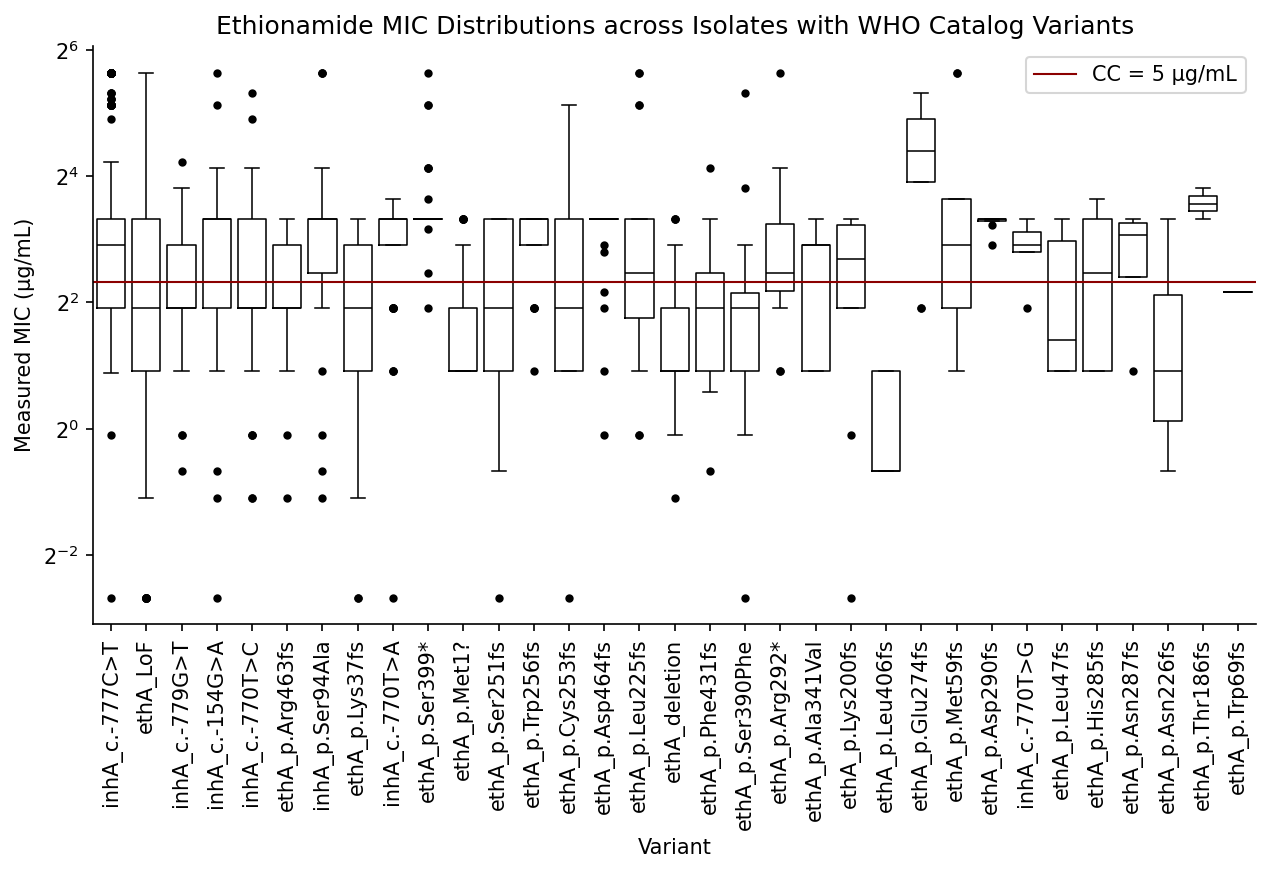

In [106]:
# keep the first 35 variants
keep_variants = df_ETO_MIC_by_resistance_variant.drop_duplicates(subset='Count').sort_values("Count", ascending=False).variant.values[:35]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_ETO_MIC_by_resistance_variant.query("variant in @keep_variants").sort_values("Count", ascending=False),
            x='variant',
            y='MIC',
            log_scale=2,
            whis=1,
            fliersize=3,
            fill=False,
            color='black',
            linewidth=0.75,
            flierprops={"markerfacecolor": "black"},
           )

plt.axhline(5, color='darkred', linewidth=1, label = "CC = 5 µg/mL")
plt.xticks(rotation=90)
plt.legend()
plt.ylabel('Measured MIC (µg/mL)')
plt.xlabel('Variant')
plt.title("Ethionamide MIC Distributions across Isolates with WHO Catalog Variants")

sns.despine()
plt.savefig("./MtbQuantCNN/results/Ethionamide/MIC_distributions_by_WHO_variant.svg", bbox_inches='tight')

## Bedaquiline

In [31]:
df_BDQ_MIC = pd.read_csv(f"{data_dir}/BDQ_augment/data_for_model.csv").query("Span_CC==0")

# df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_BDQ_pred = pd.read_csv(f"{results_dir}/BDQ_augment_amino_acid/test_predictions.csv").query("Span_CC==0")

df_BDQ_pred['y_pred_binary'] = (df_BDQ_pred['y_pred'] > np.log2(0.25)).astype(int)
df_BDQ_pred['y_pred_exp'] = np.exp2(df_BDQ_pred['y_pred'])
df_BDQ_pred['y_test_binary'] = (df_BDQ_pred['y_test'] > np.log2(0.25)).astype(int)

df_BDQ_catalog_pred = pd.read_csv(f"{results_dir}/BDQ/catalog_test_predictions_V2.csv").query("Span_CC==0")

In [32]:
missed_CNN_preds_catalog_got = list(set(df_BDQ_catalog_pred.query("y_pred==y_test & y_test==1").ROLLINGDB_ID).intersection(df_BDQ_pred.query("y_pred_binary!=y_test_binary & y_test_binary==1").Isolate))

len(missed_CNN_preds_catalog_got)

2

In [37]:
catalog_FN = len(df_BDQ_catalog_pred.query("y_pred==0 & y_test==1"))
CNN_FN = len(df_BDQ_pred.query("y_pred_binary==0 & y_test_binary==1"))

In [39]:
CNN_FN, catalog_FN

(14, 14)

In [ ]:
list(set(df_BDQ_catalog_pred.query("y_pred==y_test & y_test==1").ROLLINGDB_ID).intersection(df_BDQ_pred.query("y_pred_binary!=y_test_binary & y_test_binary==1").Isolate))

In [19]:
isolate_variants.query("ROLLINGDB_ID in @missed_CNN_preds_catalog_got & drug=='Bedaquiline' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")[['ROLLINGDB_ID', 'variant', 'confidence']]

,ROLLINGDB_ID,variant,confidence
10122,SAMN37124295,Rv0678_LoF,1) Assoc w R
369117,SAMEA7544060,Rv0678_p.Tyr92fs,2) Assoc w R - Interim
369119,SAMEA7544060,Rv0678_LoF,1) Assoc w R
730658,SAMN18498612,Rv0678_p.Ile67fs,1) Assoc w R
730660,SAMN18498612,Rv0678_LoF,1) Assoc w R


In [20]:
df_BDQ_pred.query("Isolate in @missed_CNN_preds_catalog_got")

,Isolate,y_test,lower,upper,Span_CC,y_pred,y_pred_binary,y_pred_exp,y_test_binary
632,SAMEA7544060,-1.415037,0.250000,0.500000,0,-2.147358,0,0.225726,1
1741,SAMN37124295,-1.093879,0.312000,0.625000,0,-2.080352,0,0.236457,1
1820,SAMN18498612,-0.356144,0.520833,1.041667,0,-2.036841,0,0.243697,1


In [53]:
isolate_variants.query("variant=='Rv0678_p.Gly121Arg'").merge(df_BDQ_MIC).drop_duplicates(['ROLLINGDB_ID', 'variant'])[['ROLLINGDB_ID', 'DB_OF_ORIGIN']]

,ROLLINGDB_ID,DB_OF_ORIGIN
0,SAMEA1102223,CRyPTIC
2,SAMEA8718809,CRyPTIC


In [51]:
isolate_variants.query("variant=='Rv0678_p.Leu117Arg'").merge(df_BDQ_MIC).drop_duplicates(['ROLLINGDB_ID', 'variant'])[['ROLLINGDB_ID', 'DB_OF_ORIGIN']]

,ROLLINGDB_ID,DB_OF_ORIGIN
0,SAMEA7526308,CRyPTIC
2,SAMEA7555815,CRyPTIC
4,SAMEA7562380,CRyPTIC


# Comparison with AF = 25% for Fluoroquinolones

In [82]:
df_MXF_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_lineage_amino_acid/test_predictions.csv")
df_MXF_pred_AF25 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_lineage_amino_acid/test_predictions_AF25.csv")

df_MXF_results = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_lineage_amino_acid/full_model_results.csv")
df_MXF_results_AF25 = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/MXF_lineage_amino_acid/full_model_results_AF25.csv")

In [83]:
df_MXF_results_AF25

,Unnamed: 0,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Spearman_pval,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,F1
0,0,MXF,CNN,1,0.453219,0.935375,0.961486,1.72514,0.855172,0.615738,3.828338e-197,0.848138,0.964844,0.845714,0.943236,0.906491,0.846924


In [84]:
df_MXF_results

,Unnamed: 0,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Spearman_pval,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,F1
0,0,MXF,CNN,1,0.453169,0.935143,0.961472,1.72485,0.855703,0.615576,5.173211e-197,0.848138,0.964844,0.845714,0.943236,0.906491,0.846924


In [71]:
df_combined = df_MXF_pred.merge(df_MXF_pred_AF25.rename(columns={'y_pred': 'y_pred_AF25'}))

In [52]:
# is + AF = 25% for Moxifloxacin CNN better than + AF = 75%
st.ttest_ind(df_FQ.loc[df_FQ['Additional Model Features']=='+ Lineage\n AF = 75%'].query("Drug=='Moxifloxacin' & Model=='CNN'")['Binned_MAE'],
             df_FQ.loc[df_FQ['Additional Model Features']=='+ Lineage\n AF = 25%'].query("Drug=='Moxifloxacin' & Model=='CNN'")['Binned_MAE'],
             alternative='greater',
             equal_var=False
            )

TtestResult(statistic=2.20197363148372, pvalue=0.02941014502429327, df=7.998139801375862)

In [53]:
# MXF CNN with AF = 25% is better than MXF LinReg with AF = 25%
st.ttest_ind(df_FQ.loc[df_FQ['Additional Model Features']=='+ Lineage\n AF = 25%'].query("Drug=='Moxifloxacin' & Model=='LinReg'")['Binned_MAE'],
             df_FQ.loc[df_FQ['Additional Model Features']=='+ Lineage\n AF = 25%'].query("Drug=='Moxifloxacin' & Model=='CNN'")['Binned_MAE'],
             alternative='greater',
             equal_var=False
            )

TtestResult(statistic=4.0984421374078215, pvalue=0.0045450952672177625, df=5.072395801192147)

In [20]:
# CNN + Lineage is better than CNN – Lineage
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Isoniazid'"), '+', '–', 'Binned_MAE', regression=False, direction='greater')

0.543305027825532

In [21]:
# + Lineage error is greater than - Lineage error
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Pyrazinamide'"), '+', '–', 'Binned_MAE', regression=False, direction='greater')

0.018434829160430533

In [19]:
# + Lineage error is less than - Lineage error
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Moxifloxacin'"), '+', '–', 'Binned_MAE', regression=False, direction='less')

0.000544091648822427

In [27]:
df_pvals_combined.query("Reg_better_pval <= 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
0,– Lineage,Binned_MAE,0.965847,0.034153,MXF


In [28]:
df_pvals_combined.query("CNN_better_pval <= 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
0,– Lineage,Binned_MAE,0.01388,0.98612,EMB
0,– Lineage,Binned_MAE,0.030632,0.969368,ETO
0,– Lineage,Binned_MAE,0.0003,0.9997,LFX
1,+ Lineage,Binned_MAE,0.000143,0.999857,LFX
0,– Lineage,Binned_MAE,0.000226,0.999774,PZA
1,+ Lineage,Binned_MAE,0.000787,0.999213,PZA


In [29]:
# no difference in performance between CNN and Reg
df_pvals_combined.query("Reg_better_pval > 0.05 & CNN_better_pval > 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
1,+ Lineage,Binned_MAE,0.13743,0.86257,EMB
1,+ Lineage,Binned_MAE,0.493869,0.506131,ETO
1,+ Lineage,Binned_MAE,0.2407,0.7593,MXF


In [31]:
CNN_error_summary

,Drug,Addl_Data,Binned_MAE,Binned_MAE_exp,Without_doubling,Within_doubling_perc,Doubling_Error
0,Ethambutol,+ Lineage,0.339105,1.265009,0.101552,89.844767,0.632504
1,Ethambutol,– Lineage,0.333192,1.259821,0.104156,89.584377,0.629911
2,Ethionamide,+ Lineage,0.405605,1.325518,0.136660,86.333992,0.662759
3,Ethionamide,– Lineage,0.406855,1.325839,0.118972,88.102767,0.662919
4,Levofloxacin,+ Lineage,0.184668,1.136556,0.074615,92.538462,0.568278
5,Levofloxacin,– Lineage,0.189864,1.140657,0.081923,91.807692,0.570328
6,Moxifloxacin,+ Lineage,0.467023,1.382332,0.147586,85.241379,0.691166
7,Moxifloxacin,– Lineage,0.577760,1.492713,0.200955,79.904509,0.746357
8,Pyrazinamide,+ Lineage,0.757035,1.690965,0.223415,77.658537,0.845482
9,Pyrazinamide,– Lineage,0.682616,1.605405,0.207805,79.219512,0.802702


In [22]:
CNN_error_summary.Within_doubling_perc.min(), CNN_error_summary.query("Drug != 'Pyrazinamide'").Within_doubling_perc.min(), CNN_error_summary.Within_doubling_perc.max()

(73.30232558139535, 84.65903434544549, 90.90592334494774)

In [89]:
# save the full results to the supplement
del_cols = ['Num_Loci', 'Spearman', 'Pearson', 'F1', 'MAE', 'MSE']

for col in del_cols:
    if col in df_results_combined.columns:
        del df_results_combined[col]

In [90]:
CNN_error_summary['Binned_MAE'].min(), CNN_error_summary['Binned_MAE'].max()

(0.2378607481221121, 0.8096107407249404)

In [91]:
CNN_error_summary['Doubling_Error'].min(), CNN_error_summary['Doubling_Error'].max()

(0.5896220783338084, 0.8766632025548375)

In [23]:
# regression is never better in MAE
df_pvals_combined.query("Variable == 'Binned_MAE' & Reg_better_pval <= 0.05").sort_values("Reg_better_pval", ascending=False)

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug


In [32]:
df_pvals_combined.query("CNN_better_pval <= 0.05").CNN_better_pval.max()

0.02130825674282059

In [45]:
df_pvals_combined.query("CNN_better_pval > 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Drug
0,– Lineage,Binned_MAE,0.504731,0.495269,MXF


In [40]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='EMB'"), '– Lineage', 'Binned_MAE', direction='two-sided')

nan

In [41]:
differences_significant_CNN_Reg(df_results_combined.query("Drug=='MXF'"), '– Lineage', 'Binned_MAE', direction='two-sided')

0.9905379262360383

In [21]:
# CNN + Lineage is better than CNN – Lineage
differences_significant_two_models(df_results_combined.query("Drug=='MXF'"), '+ Lineage', '– Lineage', 'Binned_MAE', regression=False, direction='less')

0.003968253968253968

In [22]:
# CNN - Lineage is better than CNN + Lineage :(. Need to remove lineage from these models then
differences_significant_two_models(df_results_combined.query("Drug=='PZA'"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

0.027777777777777776

# Pyrazinamide -/+ AA

In [34]:
df_combined_all_drugs.Addl_Data.unique()

array(['– Lineage', '+ Lineage', '– Lineage\n AF = 25%',
       '+ Lineage\n AF = 25%', '– Lineage\n– AA Properties',
       '+ Lineage\n– AA Properties', '+ Lineage\n+ Tier 2 Loci',
       '– Lineage\n+ Tier 2 Loci'], dtype=object)

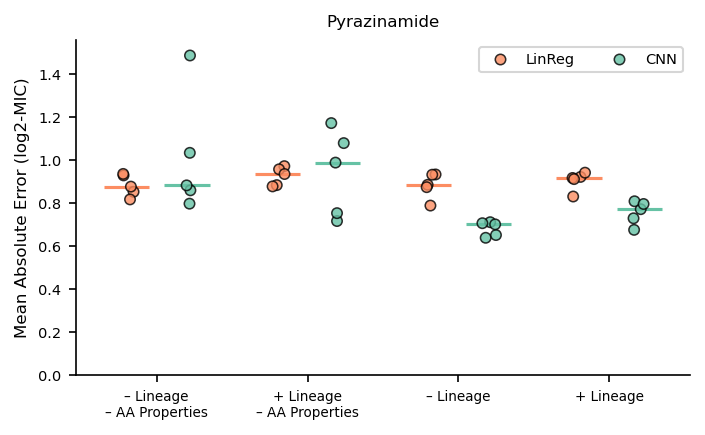

In [8]:
drug = 'PZA'
full_drug_name = abbr_drug_dict[drug]
model_order = ['– Lineage\n– AA Properties', '+ Lineage\n– AA Properties', '– Lineage', '+ Lineage']
df_pvals = get_performance_comparison_CNN_Reg(drug, df_combined_all_drugs.query("Drug==@full_drug_name"), model_order = model_order, plot_col='Binned_MAE', saveName=f"results/{full_drug_name}/MAE_without_AA_properties.svg")

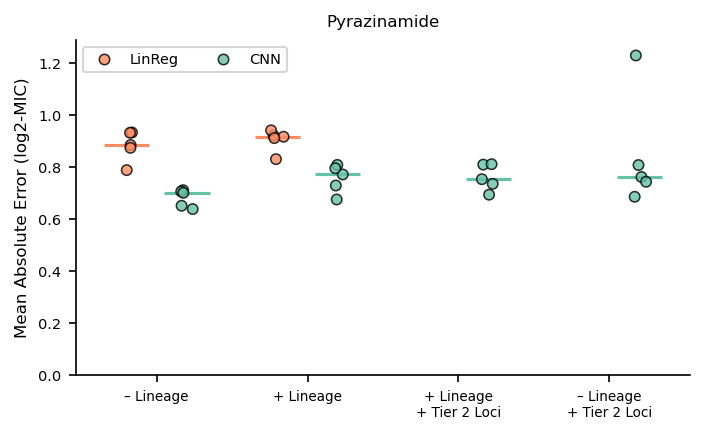

In [35]:
drug = 'PZA'
full_drug_name = abbr_drug_dict[drug]
model_order = ['– Lineage', '+ Lineage', '+ Lineage\n+ Tier 2 Loci', '– Lineage\n+ Tier 2 Loci']
df_pvals = get_performance_comparison_CNN_Reg(drug, df_combined_all_drugs.query("Drug==@full_drug_name"), model_order = model_order, plot_col='Binned_MAE', )#saveName=f"results/{full_drug_name}/MAE_without_AA_properties.svg")

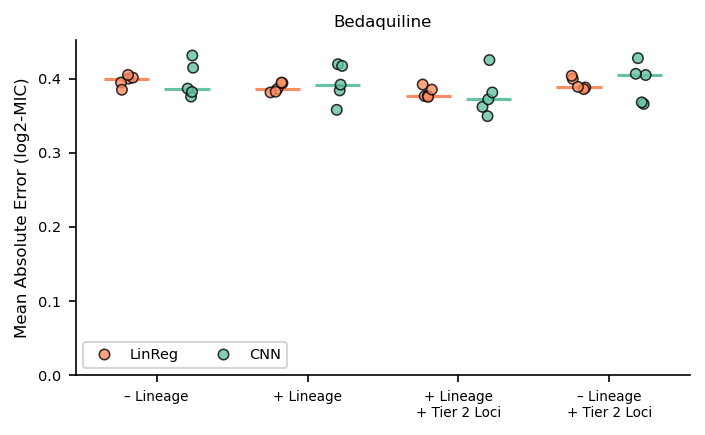

In [54]:
drug = 'BDQ'
full_drug_name = abbr_drug_dict[drug]
model_order = ['– Lineage', '+ Lineage', '+ Lineage\n+ Tier 2 Loci', '– Lineage\n+ Tier 2 Loci']
df_pvals = get_performance_comparison_CNN_Reg(drug, df_combined_all_drugs.query("Drug==@full_drug_name"), model_order = model_order, plot_col='Binned_MAE', )#saveName=f"results/{full_drug_name}/MAE_without_AA_properties.svg")

In [67]:
st.mannwhitneyu(df_combined_all_drugs.query("Drug=='Bedaquiline' & Model=='LinReg' & Addl_Data=='– Lineage'").Binned_MAE,
                df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n+ Tier 2 Loci'].query("Drug=='Bedaquiline' & Model=='LinReg'").Binned_MAE
               )

MannwhitneyuResult(statistic=16.0, pvalue=0.5476190476190477)

In [68]:
st.mannwhitneyu(df_combined_all_drugs.query("Drug=='Bedaquiline' & Model=='LinReg' & Addl_Data=='+ Lineage'").Binned_MAE,
                df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\n+ Tier 2 Loci'].query("Drug=='Bedaquiline' & Model=='LinReg'").Binned_MAE,
               )

MannwhitneyuResult(statistic=20.0, pvalue=0.15079365079365079)

In [61]:
df_combined_all_drugs.query("Drug=='Bedaquiline' & Model=='CNN'").Addl_Data.unique()

array(['– Lineage', '+ Lineage', '+ Lineage\n+ Tier 2 Loci',
       '– Lineage\n+ Tier 2 Loci'], dtype=object)

In [280]:
df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n– AA Properties'].query("Drug=='Pyrazinamide' & Model=='CNN'")['Binned_MAE'].mean()

1.0128887014067494

In [281]:
df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage'].query("Drug=='Pyrazinamide' & Model=='CNN'")['Binned_MAE'].mean()

0.6826163420656195

In [282]:
1.0128887014067494 - 0.6826163420656195

0.33027235934112986

In [278]:
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n– AA Properties'].query("Drug=='Pyrazinamide' & Model=='CNN'")['Binned_MAE'],
             df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage'].query("Drug=='Pyrazinamide' & Model=='CNN'")['Binned_MAE'],
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=2.6245443233137973, pvalue=0.028403839828585912, df=4.118934231977032)

# Loss Curves

Plot validation loss for the 5 CV replicates and the actual model on top. 

In [97]:
def plot_histories(path, patience_epochs=200, cv=True, saveName=None):

    if cv:
        combined_replicates = [pd.read_csv(fName)[['val_loss']] for fName in glob.glob(os.path.join(path, f"cross_validation/history*.csv"))]
    
    history = pd.read_csv(os.path.join(path, "history.csv"))

    if patience_epochs != 0:
        history = history.iloc[:-patience_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    if cv:
        for i, single_rep in enumerate(combined_replicates):

            if patience_epochs !=  0:
                single_rep = single_rep.iloc[:-patience_epochs, :]
                
            print(f"Trained replicate {i} for {len(single_rep)} epochs")
            
            plt.plot(single_rep.index.values + 1, single_rep['val_loss'], color="lightgray")

    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)
    print(f"Trained full model for {len(history)} epochs")

    plt.xlabel("Epoch", fontsize=10)
    plt.ylabel("Validation Loss", fontsize=10)
    
    plot_title = "Validation Loss" + " for " + os.path.basename(path) + " Model"
    plt.title(plot_title, fontsize=12)
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName)


BDQ
Trained replicate 0 for 228 epochs
Trained replicate 1 for 206 epochs
Trained replicate 2 for 265 epochs
Trained replicate 3 for 385 epochs
Trained replicate 4 for 208 epochs
Trained full model for 588 epochs

EMB
Trained replicate 0 for 258 epochs
Trained replicate 1 for 434 epochs
Trained replicate 2 for 326 epochs
Trained replicate 3 for 394 epochs
Trained replicate 4 for 253 epochs
Trained full model for 477 epochs

ETO
Trained replicate 0 for 721 epochs
Trained replicate 1 for 413 epochs
Trained replicate 2 for 419 epochs
Trained replicate 3 for 366 epochs
Trained replicate 4 for 410 epochs
Trained full model for 593 epochs

INH
Trained replicate 0 for 501 epochs
Trained replicate 1 for 484 epochs
Trained replicate 2 for 295 epochs
Trained replicate 3 for 386 epochs
Trained replicate 4 for 231 epochs
Trained full model for 607 epochs

LFX
Trained replicate 0 for 367 epochs
Trained replicate 1 for 432 epochs
Trained replicate 2 for 526 epochs
Trained replicate 3 for 453 epochs

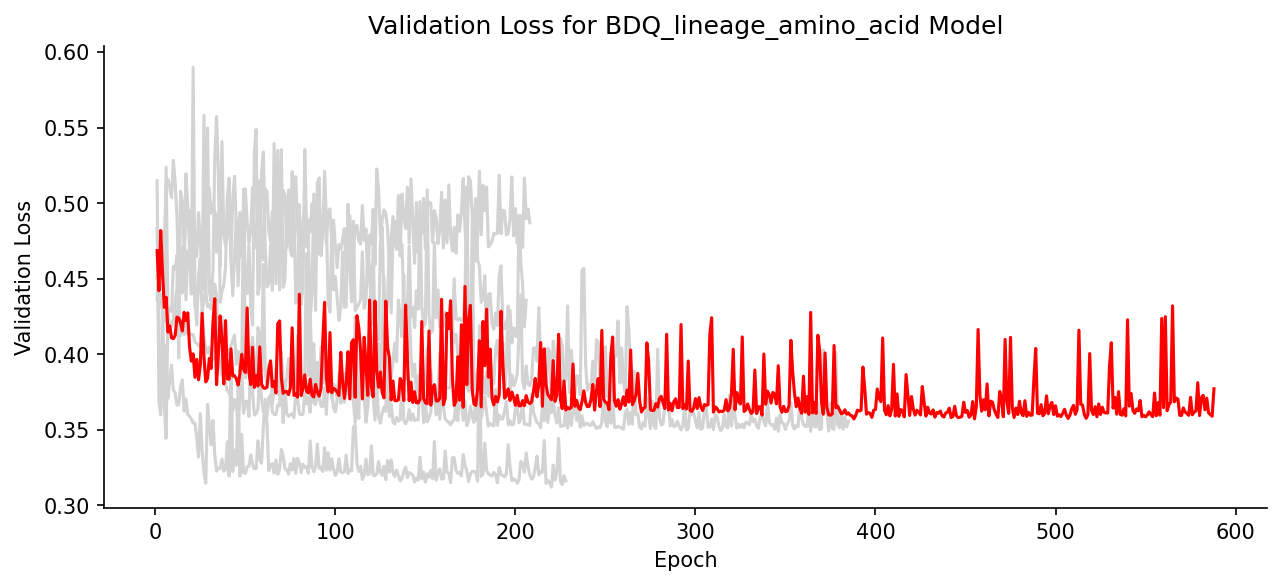

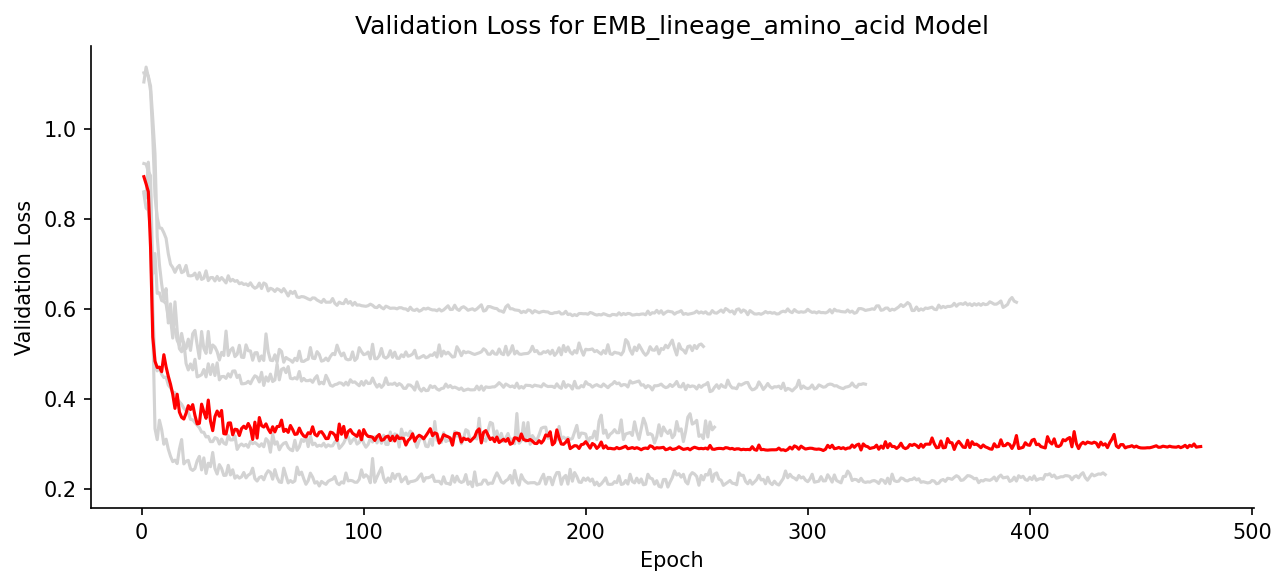

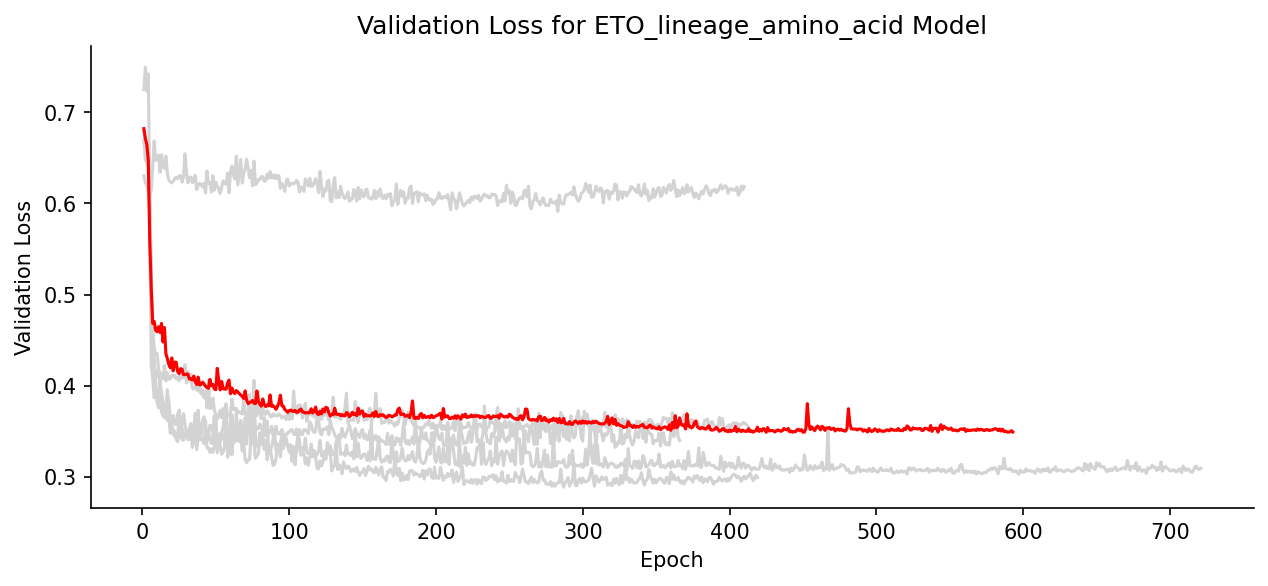

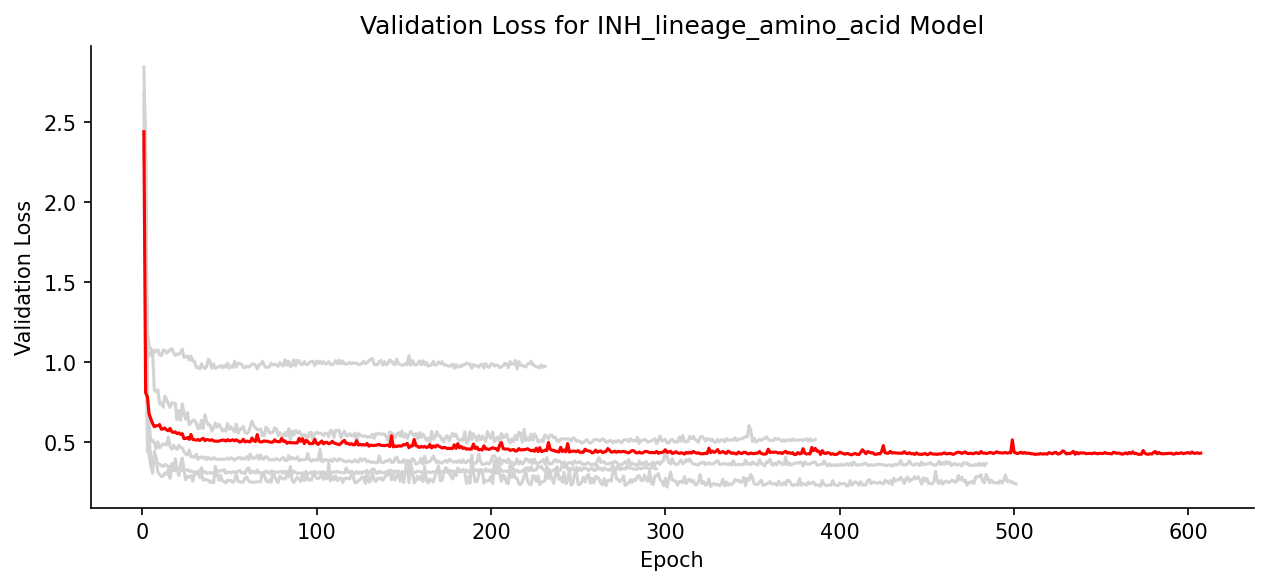

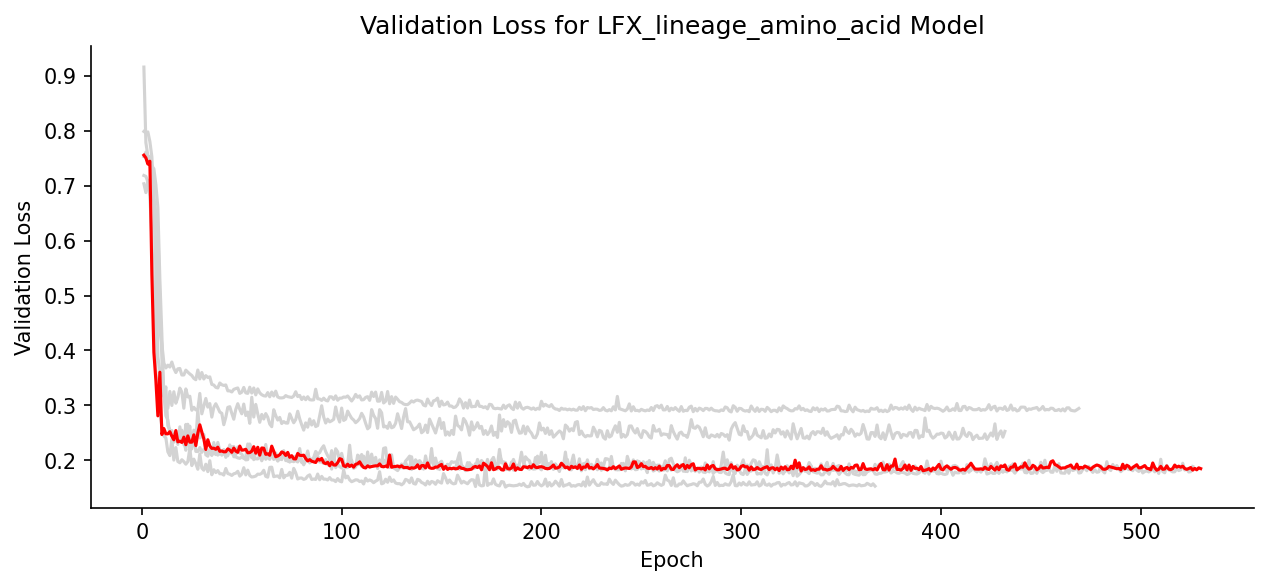

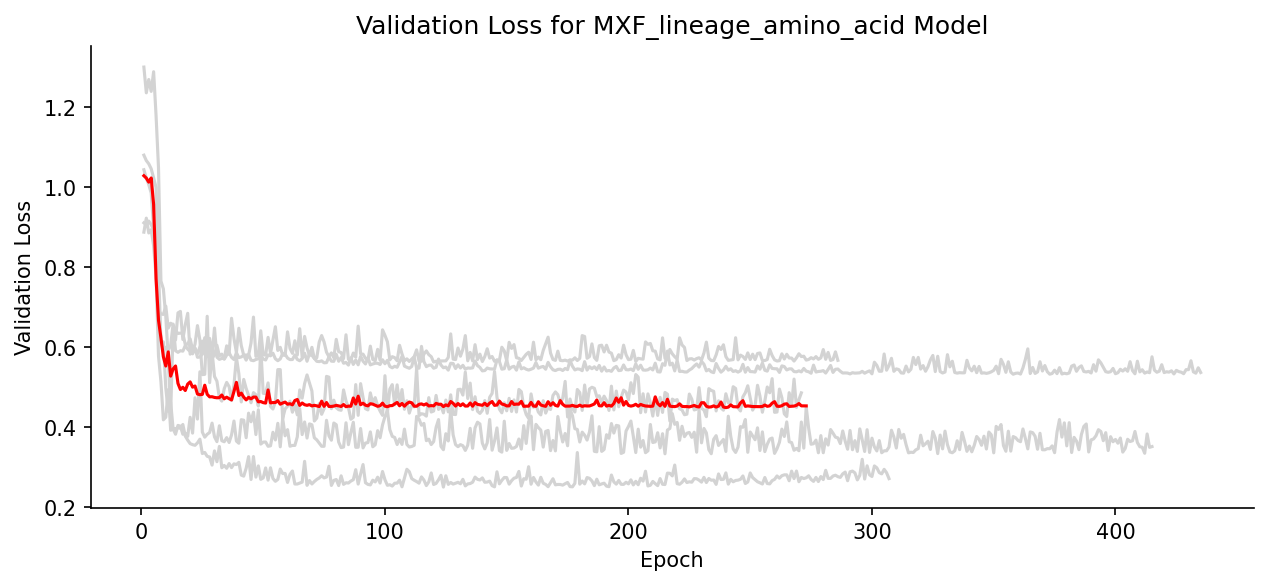

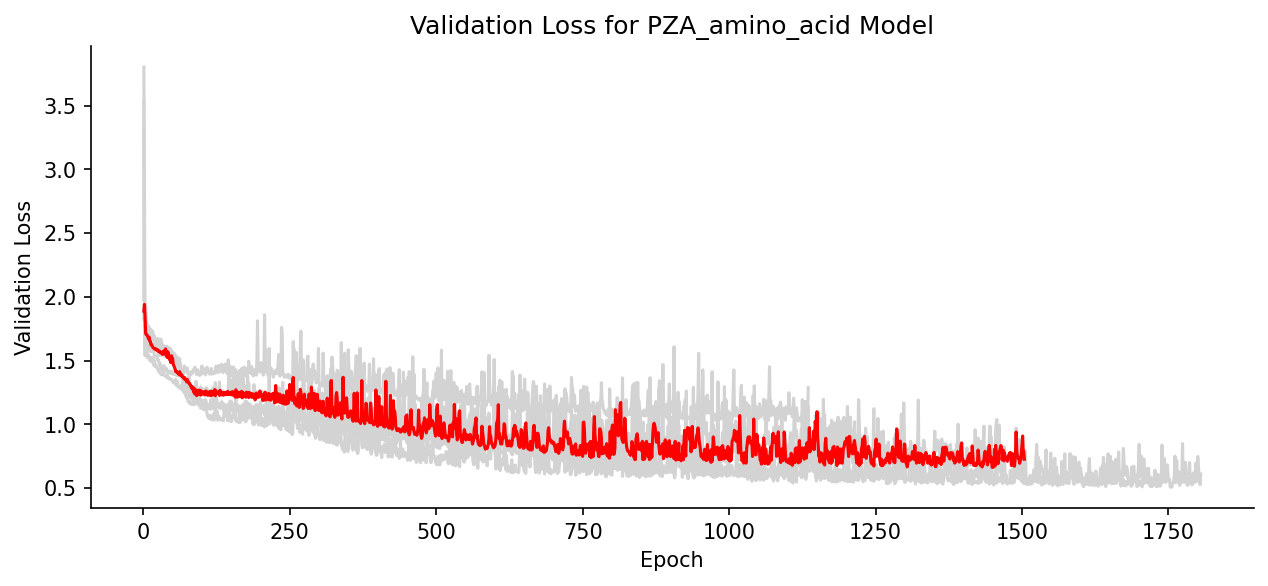

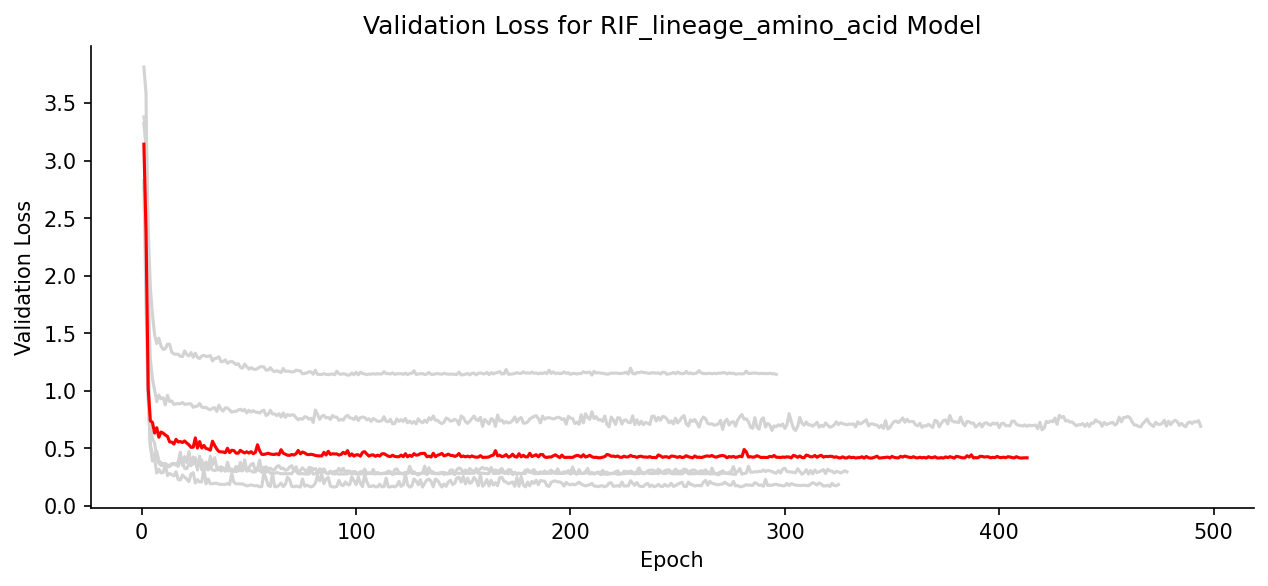

In [98]:
for drug in drugs_lst:
    
    print(f"\n{drug}")

    if drug == 'PZA':
        model_path = 'PZA_amino_acid'
    else:
        model_path = f'{drug}_lineage_amino_acid'
    
    plot_histories(os.path.join(results_dir, model_path), patience_epochs=0, cv=True, saveName=f"results/{abbr_drug_dict[drug]}/loss_curves.svg")

In [101]:
# plot_histories(os.path.join(results_dir, "PZA_peptide_amino_acid"), binary=False, patience_epochs=150, replicates=True)

In [102]:
# plot_histories(os.path.join(results_dir, "PZA_peptide"), binary=False, patience_epochs=150, replicates=True)

# Binary Statistics: Compare with 2023 WHO Catalog

## Predicted R if any 1) Assoc w R or 2) Assoc w R - Interim mutation is present

In [2]:
def compute_t_dist_confidence_interval(cv_results_df, alpha=0.05):

    metrics_lst = ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Balanced_Acc']
    
    # keep only the metrics of interest
    df_cv_metrics = pd.DataFrame(cv_results_df[metrics_lst].mean()).reset_index()

    # the mean is the test value
    df_cv_metrics.columns = ['Metric', 'Test']

    # compute standard deviation and standard error = SD / sqrt(n)
    df_std = pd.DataFrame(cv_results_df[metrics_lst].std()).reset_index()
    df_std.columns = ['Metric', 'SD']
    df_std['STD_error'] = df_std['SD'] / np.sqrt(len(cv_results_df))

    # get the critical value. Because there are 5 CV splits, and this is < 30, use the t distribution, not the standard normal
    confidence = 1 - alpha
    t_value = st.t.ppf((1 + confidence) / 2., len(cv_results_df) - 1)

    df_cv_metrics = df_cv_metrics.merge(df_std)
    df_cv_metrics['Low'] = df_cv_metrics['Test'] - t_value * df_cv_metrics['STD_error']
    df_cv_metrics['High'] = df_cv_metrics['Test'] + t_value * df_cv_metrics['STD_error']

    return df_cv_metrics[['Metric', 'Test', 'Low', 'High']]
    
    
    
def compute_exact_confidence_intervals_binary_stats(pred_df, cc, binarize=False, alpha=0.05):

    if binarize:
        pred_df['y_pred'] = (np.exp2(pred_df['y_pred']) > cc).astype(int)
        pred_df['y_test'] = (pred_df['upper'] > cc).astype(int)

    tp = len(pred_df.query("y_pred==1 & y_test==1"))
    tn = len(pred_df.query("y_pred==0 & y_test==0"))
    fn = len(pred_df.query("y_pred==0 & y_test==1"))
    fp = len(pred_df.query("y_pred==1 & y_test==0"))
    
    assert tp + tn + fn + fp == len(pred_df)

    # possible that tp + fp = 0 (meaning nothing was predicted resistant), so make ppv 0 if so, otherwsie get a divide by 0 error for ppv
    if tp + fp == 0:
        ppv = 0
    else:
        ppv = tp / (tp + fp)

    metrics_df = pd.DataFrame({'Metric': ['Sensitivity', 'Specificity', 'Precision', 'Accuracy', 'Balanced_Acc', 'F1'],
                               'Test': [tp / (tp + fn), # sensitivity
                                       tn / (tn + fp), # specificity
                                       ppv, # precision (ppv)
                                       (tp + tn) / (tp + tn + fp + fn), # accuracy
                                       0.5 * (tp / (tp + fn) + tn / (tn + fp)), # balanced accuracy
                                       tp / (tp + 0.5*(fp + fn)), # F1 score
                                       ]
                             }).set_index('Metric')

    # sensitivity
    ci = st.binomtest(k=tp, n=tp + fn, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Sensitivity', ['Low', 'High']] = [ci.low, ci.high]
    
    # specificity
    ci = st.binomtest(k=tn, n=tn + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Specificity', ['Low', 'High']] = [ci.low, ci.high]
    
    # precision (ppv)
    if tp + fp == 0:
        metrics_df.loc['Precision', ['Low', 'High']] = [0, 0]
    else:
        ci = st.binomtest(k=tp, n=tp + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
        metrics_df.loc['Precision', ['Low', 'High']] = [ci.low, ci.high]
    
    # accuracy
    ci = st.binomtest(k=tp + tn, n=tp + tn + fn + fp, p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Accuracy', ['Low', 'High']] = [ci.low, ci.high]
    
    # balanced accuracy
    ci = st.binomtest(k=tp*tn + tp*fp + tn*tp + tn*fn, n=2 * (tp + fn) * (tn + fp), p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['Balanced_Acc', ['Low', 'High']] = [ci.low, ci.high]
    
    # F1 score
    ci = st.binomtest(k=tp, n=int(tp + 0.5*(fp + fn)), p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
    metrics_df.loc['F1', ['Low', 'High']] = [ci.low, ci.high]
    
    assert sum(metrics_df['Test'] < metrics_df['Low']) == 0
    assert sum(metrics_df['Test'] > metrics_df['High']) == 0

    return metrics_df.reset_index()
    
    
    
def single_drug_binary_results(model_path, cc, V1=False, alpha=0.05):

    drug = model_path.split('_')[0]

    catalog_fName = os.path.join(results_dir, drug, "catalog_test_predictions_V2.csv")

    if V1:
        catalog_fName = catalog_fName.replace('V2', 'V1')

    # if AF_thresh != 0.75:
    #     catalog_fName = '.'.join(catalog_fName.split(".")[:-1]) + f"_AF_thresh_{int(AF_thresh*100)}." + catalog_fName.split(".")[-1]
    #     cnn_fName = os.path.join(results_dir, model_path, f"test_predictions_AF_thresh_{int(AF_thresh*100)}.csv")
    #     reg_fName = os.path.join(results_dir, model_path, f"ridge/test_predictions_AF_thresh_{int(AF_thresh*100)}.csv")
    # else:
    cnn_fName = os.path.join(results_dir, model_path, "results.csv")
    reg_fName = os.path.join(results_dir, model_path, "ridge", "results.csv")
    
    catalog_predictions = pd.read_csv(catalog_fName)
    catalog_metrics_df = compute_exact_confidence_intervals_binary_stats(catalog_predictions, cc, alpha=alpha)

    # cnn_predictions = pd.read_csv(os.path.join(results_dir, model_path, "test_predictions.csv"))
    # reg_predictions = pd.read_csv(os.path.join(results_dir, model_path, "ridge", "test_predictions.csv"))
    # cnn_metrics_df = compute_exact_confidence_intervals_binary_stats(cnn_predictions, cc, binarize=True, alpha=alpha)
    # reg_metrics_df = compute_exact_confidence_intervals_binary_stats(reg_predictions, cc, binarize=True, alpha=alpha)

    # use the CV results and compute 95% confidence intervals using the t stat
    cnn_results = pd.read_csv(cnn_fName)
    reg_results = pd.read_csv(reg_fName)
    cnn_metrics_df = compute_t_dist_confidence_interval(cnn_results, alpha=alpha)
    reg_metrics_df = compute_t_dist_confidence_interval(reg_results, alpha=alpha)

    catalog_metrics_df['Model'] = 'Catalog'
    cnn_metrics_df['Model'] = 'CNN'
    reg_metrics_df['Model'] = 'Regression'

    return pd.concat([catalog_metrics_df, cnn_metrics_df, reg_metrics_df], axis=0)



def plot_single_drug_all_metrics(model_path, cc, save=False, V1=False):

    metrics_lst = ['Sensitivity', 'Specificity', 'Precision', 'F1']
    
    drug = model_path.split("_")[0]

    # get binary metrics and exact confidence intervals
    df_metrics = single_drug_binary_results(model_path, cc, V1=V1)

    categories = ['Catalog', 'Regression', 'CNN']
    df_metrics = df_metrics.set_index(["Model", "Metric"])
    
    palette=dict(zip(["CNN", "Regression", "Catalog"], sns.color_palette("Set2").as_hex()))

    # Bar width and positions
    bar_width = 0.05
    # bar_positions = np.arange(len(categories))
    
    errwidth = 0.04
    errlinewidth = 0.5
    
    fig, axs = plt.subplots(1, len(metrics_lst), figsize=(len(metrics_lst)*2, 3), sharex=True, sharey=True)
    axs = axs.flatten()

    for i, metric in enumerate(metrics_lst):

        ax = axs[i]
        
        # Plot bars for each category
        for j, category in enumerate(categories):
        
            # plot_df.loc['Catalog', 'Sensitivity']['Test']
            
            test = df_metrics.loc[category, metric]["Test"] * 100
            lower = df_metrics.loc[category, metric]["Low"] * 100
            upper = df_metrics.loc[category, metric]["High"] * 100
            
            # Plot the test value as a bar
            patch = ax.bar(j, test, color=palette[category], label=category, linewidth=0.5, edgecolor='black')
            ax.bar_label(patch, label_type='center', fmt='%.1f', fontsize=9)
            
            # Plot the confidence interval as a vertical line
            ax.vlines(j, lower, upper, color='black', linewidth=errlinewidth)
        
            # plot horizontal lines to make the error bars look nicer
            ax.hlines(lower, j - errwidth, j + errwidth, color='black', linewidth=errlinewidth)
            ax.hlines(upper, j - errwidth, j + errwidth, color='black', linewidth=errlinewidth)
        
        ax.set_title(metric, fontsize=10)
        
        # remove x-axis ticks and labels
        ax.set_xticks([])
        ax.set_xticklabels([])
    
    # Show the plot
    plt.ylim(0, 100)
    plt.suptitle(f"{abbr_drug_dict[drug]}\n\n", y=1.02)
    plt.legend(bbox_to_anchor=(0.2, -0.15), loc="lower right", ncol=len(categories), fontsize=8)
    sns.despine()
    plt.tight_layout()

    if save:
        plt.savefig(f"results/{abbr_drug_dict[drug]}/binary_metrics_comparison.svg", bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [3]:
def plot_single_metric_all_drugs(metric, save=False, V1=False):

    df_metrics_all_drugs = []
    
    for drug in np.sort(os.listdir(data_dir)):

        # model_path = f"{drug}_amino_acid"
        
        if drug == 'PZA':
            model_path = f"{drug}_amino_acid"
        else:
            model_path = f"{drug}_lineage_amino_acid"
    
        df_metrics = single_drug_binary_results(model_path, cc_dict[drug], V1=V1)
        
        # if drug == 'ETH':
        #     df_metrics['Drug'] = 'ETO'
        # elif drug == 'LEV':
        #     df_metrics['Drug'] = 'LFX'
        # else:
        #     df_metrics['Drug'] = drug
    
        df_metrics['Drug'] = abbr_drug_dict[drug]
        
        df_metrics_all_drugs.append(df_metrics)
    
    df_metrics_all_drugs = pd.concat(df_metrics_all_drugs)
    
    categories = ['CNN', 'Regression', 'Catalog']
    
    drugs_lst = np.sort(df_metrics_all_drugs.Drug.unique())
    
    df_metrics_all_drugs = df_metrics_all_drugs.set_index(["Drug", "Model", "Metric"])
    
    palette = dict(zip(categories, sns.color_palette("Set2").as_hex()))

    categories = ['CNN', 'Catalog']
    
    # Bar width and positions
    bar_width = 0.25
    group_width = bar_width * len(categories)
    group_gap = 0.2  # Gap between groups of bars
    errwidth = 0.04
    errlinewidth = 0.5
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    
    # Initialize the position for the first bar
    bar_idx = 0
    
    for drug_idx, drug in enumerate(drugs_lst):
        
        # Compute the position for each category within this drug group
        for cat_idx, category in enumerate(categories):
            
            # Calculate the bar position
            position = drug_idx * (group_width + group_gap) + cat_idx * bar_width
            
            test = df_metrics_all_drugs.loc[drug, category, metric]["Test"] * 100
            lower = df_metrics_all_drugs.loc[drug, category, metric]["Low"] * 100
            upper = df_metrics_all_drugs.loc[drug, category, metric]["High"] * 100
            
            # Plot the test value as a bar
            patch = ax.bar(position, test, bar_width, color=palette[category], label=category if bar_idx < len(categories) else "", linewidth=0.5, edgecolor='black')
            ax.bar_label(patch, label_type='center', fmt='%.1f', fontsize=8)
            
            # Plot the confidence interval as a vertical line
            ax.vlines(position, lower, upper, color='black', linewidth=errlinewidth)
        
            # Plot horizontal lines to make the error bars look nicer
            ax.hlines(lower, position - errwidth, position + errwidth, color='black', linewidth=errlinewidth)
            ax.hlines(upper, position - errwidth, position + errwidth, color='black', linewidth=errlinewidth)
    
            bar_idx += 1
    
    # Add drug labels in the middle of each group
    drug_positions = [drug_idx * (group_width + group_gap) + group_width / 2 - bar_width / 2 for drug_idx in range(len(drugs_lst))]
    ax.set_xticks(drug_positions)
    ax.set_xticklabels(drugs_lst, ha='center', fontsize=9)
    
    ax.set_ylabel(f"{metric} (%)", fontsize=10)
    
    # Show the legend only once
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(categories)], labels[:len(categories)], bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
    
    # Show the plot
    plt.ylim(0, 100)
    sns.despine()
    plt.tight_layout()
    
    if save:
        plt.savefig(f"results/{metric}_comparison.svg", bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [4]:
# metrics_lst = ['Sensitivity', 'Specificity', 'Precision']#, 'F1']

# for metric in metrics_lst:
#     plot_single_metric_all_drugs(metric, save=False, V1=False)

In [11]:
drug = 'RIF'

df_metrics = single_drug_binary_results(f"{drug}_lineage_amino_acid", cc_dict[drug])

In [12]:
df_metrics.query("Metric=='Sensitivity'")

,Metric,Test,Low,High,Model
0,Sensitivity,0.958763,0.945695,0.969441,Catalog
0,Sensitivity,0.965720,0.964193,0.967246,CNN
0,Sensitivity,0.964986,0.960549,0.969423,Regression


In [13]:
df_metrics.query("Metric=='Specificity'")

,Metric,Test,Low,High,Model
1,Specificity,0.971329,0.959970,0.980184,Catalog
1,Specificity,0.977932,0.975334,0.980530,CNN
1,Specificity,0.975847,0.973772,0.977922,Regression


In [30]:
cnn_fName = os.path.join(results_dir, "LEV_lineage_amino_acid", "results.csv")

# use the CV results and compute 95% confidence intervals using the t stat
cnn_results = pd.read_csv(cnn_fName)

In [31]:
cnn_results

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,CV
0,LEV,CNN,1,0.234814,0.476742,0.726575,0.993871,0.908716,0.629819,0.816941,0.899687,0.986222,0.937908,0.969965,0.942954,0
1,LEV,CNN,1,0.249212,0.494385,0.722731,1.005202,0.905771,0.637729,0.814894,0.899687,0.986222,0.937908,0.969965,0.942954,1
2,LEV,CNN,1,0.240048,0.498201,0.736170,1.027366,0.914605,0.628363,0.810864,0.893417,0.986222,0.937500,0.968787,0.939819,2
3,LEV,CNN,1,0.240393,0.483121,0.731252,1.003942,0.914605,0.643218,0.815091,0.893417,0.986222,0.937500,0.968787,0.939819,3
4,LEV,CNN,1,0.239225,0.483741,0.734343,1.009103,0.923439,0.636392,0.815726,0.902821,0.986222,0.938111,0.970554,0.944522,4


# Which Isolates Were Missed by CNN but not by Catalog?

In [21]:
df_model_select = df_combined_all_drugs.query("Model=='CNN' & Addl_Data == '+ Lineage'")

df_model_select.groupby(['Drug'])[['Sensitivity', 'Specificity']].mean()

,Sensitivity,Specificity
Drug,,
Bedaquiline,0.046154,0.998000
Ethambutol,0.790164,0.895028
Ethionamide,0.665875,0.947362
Isoniazid,0.929403,0.970486
Levofloxacin,0.913311,0.980426
Moxifloxacin,0.856734,0.964974
Pyrazinamide,0.747170,0.925253
Rifampicin,0.964336,0.979690


In [38]:
df_model_select.groupby(['Drug'])[['Sensitivity', 'Specificity']].std()

,Sensitivity,Specificity
Drug,,
BDQ,0.126760,0.001807
EMB,0.049752,0.018434
ETH,0.032150,0.010700
INH,0.006321,0.003694
LEV,0.004206,0.000000
MXF,0.007226,0.002051
PZA,0.025937,0.009617
RIF,0.001230,0.002092


In [175]:
isolate_variants.query("GENE=='pncA' & variant == 'pncA_p.Thr160_Ala171del'")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
85066,2288728,GCGCGGCGACGGTGGTATCGGCCGACACACCCGCTGT,G,PASS,0.0,False,0.33,44.0,33.0,50.0,0.0,12.0,conservative_inframe_deletion,pncA,c.478_513delACAGCGGGTGTGTCGGCCGATACCACCGTCGCCGCG,p.Thr160_Ala171del,pncA_p.Thr160_Ala171del,Pyrazinamide,3) Uncertain significance,SAMEA3402850


In [180]:
df_phenos.query("ROLLINGDB_ID=='SAMEA3402850'")

,ROLLINGDB_ID,DB_OF_ORIGIN,MEDIA,MEDIA_NORM,PZA_lower_bound,PZA_midpoint,PZA_upper_bound,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
13,SAMEA3402850,farhat_internal,MGIT,MGIT,20.0,35.0,50.0,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.011348,2.2.1,2.2.1.1.1.i3,beijing,"lin2.2.1,central_asia",NaN,2,0,0.0,2-0,test_set


In [178]:
df_phenos = pd.read_csv(os.path.join(data_dir, "PZA", "data_for_model.csv"))

In [ ]:
There are 6 BDQ-R isolates missed by the CNN. However, three isolates (YA00080757, SAMEA7526214, and SAMEA8718989) that contain Rv0678_p.Glu49fs have CNN-predicted MICs of 0.246, 0.247, and 0.222 µg/mL, just under the critical concentration of 0.25 µg/mL.

In [88]:
df_BDQ_pred = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/BDQ_lineage_amino_acid/test_predictions.csv")
BDQ_results = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/CNN_results/BDQ_lineage_amino_acid/results.csv")

df_BDQ_pred['y_pred_MIC'] = np.exp2(df_BDQ_pred['y_pred'])

df_BDQ_train_test = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/BDQ/data_for_model.csv")

In [43]:
BDQ_results

,Drug,Model,Num_Loci,Binned_MAE,Binned_MSE,MAE,MSE,Within_doubling,Spearman,Pearson,Sensitivity,Specificity,Precision,Accuracy,Balanced_Acc,F1,CV
0,BDQ,CNN,4,0.405376,0.623755,0.938824,1.474401,0.908590,0.360087,0.399462,0.304348,0.997769,0.636364,0.988987,0.651058,0.411765,0
1,BDQ,CNN,4,0.445837,0.718259,0.995798,1.666946,0.911344,0.253792,0.226944,0.000000,1.000000,NaN,0.987335,0.500000,0.000000,1
2,BDQ,CNN,4,0.432780,0.636357,0.938560,1.501663,0.907489,0.350462,0.389543,0.217391,0.998327,0.625000,0.988436,0.607859,0.322581,2
3,BDQ,CNN,4,0.406126,0.621738,0.940950,1.472558,0.908590,0.364473,0.399780,0.260870,0.997769,0.600000,0.988436,0.629319,0.363636,3
4,BDQ,CNN,4,0.435521,0.674510,0.959324,1.579684,0.917952,0.291723,0.325672,0.304348,0.994980,0.437500,0.986233,0.649664,0.358974,4


In [54]:
# inspect variants in isolates with predicted MICs below 1 doubling from CC
# prediction for H37Rv from insilico predictions notebook is 0.030083
df_BDQ_pred.query("lower >= 0.25 & y_pred_MIC < 0.125").sort_values("y_pred_MIC", ascending=False)

,Isolate,y_test,lower,upper,Span_CC,y_pred,y_pred_MIC
1076,SAMEA7561566,-1.415037,0.25,0.5,0,-3.023532,0.122978
1509,SAMEA8719070,-1.415037,0.25,0.5,0,-3.108438,0.115949
1526,SAMEA8719169,-0.415037,0.50,1.0,0,-4.008802,0.062120
1508,SAMEA8719064,-0.415037,0.50,1.0,0,-4.126898,0.057237
1078,SAMEA7561581,-1.415037,0.25,0.5,0,-4.141563,0.056659
611,SAMEA7544011,-1.415037,0.25,0.5,0,-4.942358,0.032524
484,SAMEA7541600,0.584963,1.00,2.0,0,-5.001533,0.031217
286,SAMEA7525181,1.000000,2.00,inf,0,-5.031787,0.030569
1610,SAMEA8741718,-0.415037,0.50,1.0,0,-5.055197,0.030077
1621,SAMEA8741761,-0.415037,0.50,1.0,0,-5.055197,0.030077


In [84]:
# prediction for H37Rv from insilico predictions notebook is 0.030083
h37Rv_pred = 0.030083
high_MIC_pred_lower_than_H37Rv = df_BDQ_pred.query("lower >= 0.25 & y_pred_MIC <= @h37Rv_pred").sort_values("y_pred_MIC", ascending=False)

In [67]:
# none of the isolates with predicted MICs at or below 0.03 has any Group 1-2 variants --> good
isolate_variants.query("ROLLINGDB_ID in @high_MIC_pred_lower_than_H37Rv.Isolate & drug == 'Bedaquiline' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID


In [85]:
# prediction for H37Rv from insilico predictions notebook is 0.030083
high_MIC_pred_lower_doubling_CC = df_BDQ_pred.query("lower >= 0.25 & y_pred_MIC <= 0.125 & y_pred_MIC > @h37Rv_pred").sort_values("y_pred_MIC", ascending=False)

In [87]:
isolate_variants.query("ROLLINGDB_ID in @high_MIC_pred_lower_doubling_CC.Isolate & drug == 'Bedaquiline' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID
506557,779407,C,CG,Amb,3215.0,False,0.65,93.0,35.0,60.0,60.0,0.0,frameshift_variant,Rv0678,c.421dupG,p.Asp141fs,Rv0678_p.Asp141fs,Bedaquiline,2) Assoc w R - Interim,SAMEA7561566
650141,779430,G,GA,PASS,5942.0,False,0.71,175.0,34.0,60.0,124.0,0.0,frameshift_variant,Rv0678,c.443dupA,p.Asn148fs,Rv0678_p.Asn148fs,Bedaquiline,2) Assoc w R - Interim,SAMEA8719070
654733,2859601,A,AC,PASS,4500.0,False,0.94,126.0,36.0,60.0,119.0,0.0,frameshift_variant,pepQ,c.817dupG,p.Val273fs,pepQ_p.Val273fs,Bedaquiline,2) Assoc w R - Interim,SAMEA8719169


In [102]:
BDQ_isolates_Rv0678_train_test = isolate_variants.query("ROLLINGDB_ID in @df_BDQ_train_test.ROLLINGDB_ID & drug=='Bedaquiline' & GENE=='Rv0678' & variant.str.contains('fs')").merge(df_BDQ_train_test[['ROLLINGDB_ID', 'category']])

BDQ_isolates_pepQ_train_test = isolate_variants.query("ROLLINGDB_ID in @df_BDQ_train_test.ROLLINGDB_ID & drug=='Bedaquiline' & GENE=='pepQ' & variant.str.contains('fs')").merge(df_BDQ_train_test[['ROLLINGDB_ID', 'category']])

In [100]:
BDQ_isolates_Rv0678_train_test.groupby('category')['variant'].nunique()

category
test_set     12
train_set    21
Name: variant, dtype: int64

In [101]:
set(BDQ_isolates_Rv0678_train_test.query("category=='test_set'").variant) - set(BDQ_isolates_Rv0678_train_test.query("category=='train_set'").variant)

{'Rv0678_p.Ala144fs',
 'Rv0678_p.Arg72fs',
 'Rv0678_p.Asn148fs',
 'Rv0678_p.Leu142fs',
 'Rv0678_p.Pro129fs'}

In [103]:
set(BDQ_isolates_pepQ_train_test.query("category=='test_set'").variant) - set(BDQ_isolates_pepQ_train_test.query("category=='train_set'").variant)

set()

In [106]:
df_BDQ_train_test.query("ROLLINGDB_ID in @BDQ_isolates_pepQ_train_test.ROLLINGDB_ID")

,ROLLINGDB_ID,MEDIA_NORM,BDQ_lower_bound,BDQ_midpoint,BDQ_upper_bound,MEDIA,DB_OF_ORIGIN,VCF,F2,Coll2014,Freschi2020,Lipworth2019,Shitikov2017,Stucki2016,Lineage,Span_CC,Binary,Stratify,category
3409,SAMEA7544303,7H11,0.12,0.185000,0.250000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.007575,2.2.2,2.2.2,"beijing,canetti,mungi","asia_ancestral_1,lin2.2",NaN,2,0,0.0,2-0,train_set
7501,SAMEA8718862,7H11,0.12,0.185000,0.250000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.010785,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,2,0,0.0,2-0,train_set
7553,SAMEA8718944,7H11,0.12,0.185000,0.250000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.005989,4.3.3,4.2.1.2.1.1.i4.1,lam,NaN,4.3/LAM,4,0,0.0,4-0,train_set
7682,SAMEA8719169,7H11,0.50,0.750000,1.000000,UKMYC,CRyPTIC,/n/data1/hms/dbmi/farhat/rollingDB/cryptic_out...,0.009539,2.2.2,2.2.2,"beijing,mungi","asia_ancestral_1,lin2.2",NaN,2,0,1.0,2-1,test_set
9051,SAMEA5282371,NaN,0.00,0.000694,0.001389,NaN,Alland,/n/data1/hms/dbmi/farhat/rollingDB/genomic_dat...,0.013239,4.4.1.1,4.2.1.2.2.1.1,stype,NaN,4,4,0,0.0,4-0,train_set


In [104]:
BDQ_isolates_pepQ_train_test

,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,...,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence,ROLLINGDB_ID,category
0,2859470,G,GT,PASS,11041.0,False,1.00,287.0,38.0,60.0,...,0.0,frameshift_variant,pepQ,c.948dupA,p.Leu317fs,pepQ_p.Leu317fs,Bedaquiline,2) Assoc w R - Interim,SAMEA7544303,train_set
1,2860120,T,TG,PASS,5882.0,False,0.98,164.0,36.0,60.0,...,0.0,frameshift_variant,pepQ,c.298dupC,p.His100fs,pepQ_p.His100fs,Bedaquiline,2) Assoc w R - Interim,SAMEA8718862,train_set
2,2859601,A,AC,PASS,5263.0,False,0.98,145.0,36.0,60.0,...,0.0,frameshift_variant,pepQ,c.817dupG,p.Val273fs,pepQ_p.Val273fs,Bedaquiline,2) Assoc w R - Interim,SAMEA8718944,train_set
3,2859601,A,AC,PASS,4500.0,False,0.94,126.0,36.0,60.0,...,0.0,frameshift_variant,pepQ,c.817dupG,p.Val273fs,pepQ_p.Val273fs,Bedaquiline,2) Assoc w R - Interim,SAMEA8719169,test_set
4,2859601,A,AC,Amb,8462.0,False,0.38,236.0,36.0,59.0,...,0.0,frameshift_variant,pepQ,c.817dupG,p.Val273fs,pepQ_p.Val273fs,Bedaquiline,2) Assoc w R - Interim,SAMEA5282371,train_set


In [ ]:
# none of the isolates with predicted MICs at or below 0.03 has any Group 1-2 variants --> good
isolate_variants.query("ROLLINGDB_ID in @high_MIC_pred_lower_than_H37Rv.Isolate & drug == 'Bedaquiline' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']")

In [69]:
isolate_variants.ROLLINGDB_ID.nunique()

14133

In [83]:
set(samples_geno.query("DB_OF_ORIGIN != 'TRUST'").ROLLINGDB_ID) - set(isolate_variants.ROLLINGDB_ID)

{'SAMEA7562405', 'SAMEA8718614'}

In [81]:
samples_geno = pd.read_csv("data_processing/samples_pass_geno_QC.csv")

In [56]:
isolate_variants.query("ROLLINGDB_ID=='SAMEA7561566'").confidence.value_counts()

confidence
5) Not assoc w R              38
4) Not assoc w R - Interim    11
3) Uncertain significance      4
2) Assoc w R - Interim         3
1) Assoc w R                   2
Name: count, dtype: int64

# Ethionamide Analysis:

### How many ETO-R isolates don't have Group 1-2 variants but have interesting mshA variants?

In [31]:
df_ETO = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs/ETO/data_for_model.csv")
WHO_predictions = extract_WHO_resistance_predictions(df_ETO, 'ROLLINGDB_ID')

# get samples that are phenotypically resistant but genotypically susceptible according to the WHO catalog
ETO_R_samples_pred_S_catalog = list(set(df_ETO.query("ETO_lower_bound >= 5").ROLLINGDB_ID).intersection(WHO_predictions.query("Drug=='Ethionamide' & Phenotype=='S'").ROLLINGDB_ID))
len(ETO_R_samples_pred_S_catalog)

302

In [ ]:
eto_loci = 

In [34]:
kwargs = yaml.safe_load(open("config_files/config_eto.yaml", "r"))

In [46]:
kwargs['tier1_loci']# + kwargs['tier2_loci']

['fabG1-inhA', 'ethA', 'ethR', 'mshA']

In [45]:
# exclude the two polymorphisms
isolate_variants.query("ROLLINGDB_ID in @ETO_R_samples_pred_S_catalog & drug=='Ethionamide' & GENE == 'mshA' & EFFECT != 'synonymous_variant' & variant not in ['mshA_p.Ala187Val', 'mshA_p.Asn111Ser']").variant.value_counts()

variant
mshA_p.Leu405Arg           2
mshA_p.Ala279fs            2
mshA_p.Ala189fs            1
mshA_p.Gly311*             1
mshA_p.Ala2Thr             1
mshA_p.Ala422fs            1
mshA_p.Leu137Pro           1
mshA_p.Pro280His           1
mshA_p.Ala182Thr           1
mshA_p.Gly67Ala            1
mshA_p.Thr176fs            1
mshA_p.Pro197fs            1
mshA_p.Ser352His           1
mshA_p.Asp218Ala           1
mshA_p.His53fs             1
mshA_p.Leu188Val           1
mshA_p.Val238fs            1
mshA_deletion              1
mshA_p.Leu157fs            1
mshA_p.Val224_Ser226del    1
mshA_p.Asp400fs            1
Name: count, dtype: int64

In [42]:
isolate_variants.query("GENE=='mshA' & confidence=='5) Not assoc w R'").variant.unique()

array(['mshA_p.Ala187Val', 'mshA_p.Asn111Ser', 'mshA_c.21T>C',
       'mshA_c.730C>T'], dtype=object)

In [39]:
isolate_variants.query("ROLLINGDB_ID in @ETO_R_samples_pred_S_catalog & drug=='Ethionamide' & EFFECT != 'synonymous_variant'").variant.value_counts()

variant
Rv0565c_p.Arg110His    90
Rv0565c_p.Ser68Pro     89
mshA_p.Ala187Val       76
mshA_p.Asn111Ser       23
Rv3083_p.Asp71His      17
                       ..
ethA_c.-12T>C           1
inhA_p.Ile21Val         1
ethA_p.Leu129Pro        1
ethA_p.Pro257Gln        1
mshA_p.Asp400fs         1
Name: count, Length: 186, dtype: int64